# Notebook 06 — Robustness Validation

> **Supplementary §8**

This notebook performs comprehensive null hypothesis testing and robustness checks to validate that the observed high structure in the morphing shape mode PCA reflects genuine biological organisation rather than artefacts of marker layout, labelling, missing data, or statistical chance.

PCA always produces ordered components -- even from purely random data -- so a steep eigenvalue curve alone does not prove that the extracted modes are meaningful. The tests below subject the analysis to six independent challenges, each designed to break a specific assumption. If the dominant subspace survives all of them, we can conclude that the low-dimensional structure is a property of the hawks' morphing geometry, not of our processing pipeline.

## Contents
1. [Eigenvalue significance (Ψ and Φ)](#81-eigenvalue-significance)
2. [Shuffled dataset controls](#82-shuffled-dataset-controls)
3. [Marker subsampling](#83-marker-subsampling)
4. [Pairwise distance PCA (label-free)](#84-pairwise-distance-pca)
5. [Random relabelling](#85-random-relabelling)
6. [Missing data imputation](#86-missing-data-imputation)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True, precision=4)

from kinematic_morphospace import (
    filter_by, run_PCA, to_unilateral,
    principal_cosines, pairwise_distance_features,
)
from kinematic_morphospace.null_testing import (
    flatten_frames, validate_frame_alignment, prepare_sequence_groups,
    sequence_lookup, grouped_bootstrap_indices, summarise_distribution,
    summarise_cumulative_variance, random_relabel_frames, ensure_rng,
)
from kinematic_morphospace.validation import calculate_phi
from kinematic_morphospace.plotting import (
    plot_explained, save_figure,
    plot_shuffle_schematic, plot_subsampling_schematic,
    plot_pairwise_distance_schematic, plot_relabelling_schematic,
    plot_imputation_schematic,
    plot_shuffle_composite, plot_subsampling_composite,
    plot_pairwise_composite, plot_relabelling_composite,
    plot_imputation_composite,
)

## Configuration

All configurable parameters are gathered in a single dictionary for reproducibility. The random seed fixes every stochastic operation; `n_permutations` and `n_boot` control the resolution of the null distributions.

In [2]:
# --- Configuration ---
CONFIG = {
    "rng_seed": 123,
    "n_components": 12,
    "n_permutations": 2000,
    "n_boot": 500,
    "k_report": [1, 2, 3, 4, 6, 9, 12],
}

# --- Load data ---
unilateral_data = np.load("../../data/unilateral/data.npy")
frame_info = pd.read_csv("../../data/unilateral/frame_info.csv")

validate_frame_alignment(unilateral_data, frame_info)

# Prepare sequence groups for resampling
groups = prepare_sequence_groups(frame_info)
seq_index = groups["seq_index"]
seq_lut = sequence_lookup(seq_index)

# Training mask: non-obstacle flights
straight_mask = filter_by(frame_info, obstacle=0)

# Flatten for feature-level operations
frames_flat = flatten_frames(unilateral_data)
straight_flat = frames_flat[straight_mask]

n_frames = unilateral_data.shape[0]
n_markers = unilateral_data.shape[1]
n_sequences = len(np.unique(seq_index))
n_birds = frame_info["BirdID"].nunique()

print(f"Frames: {n_frames:,}")
print(f"Markers per side: {n_markers}")
print(f"Sequences: {n_sequences:,}")
print(f"Hawks: {n_birds}")
print(f"Straight-flight frames: {straight_mask.sum():,}")

Frames: 289,528
Markers per side: 4
Sequences: 1,634
Hawks: 5
Straight-flight frames: 252,630


## Observed PCA baseline

Run PCA on straight-flight frames to establish the baseline cumulative explained variance (CEV) that all subsequent tests will be compared against. These are the markers with the whole body rotations removed as described in Notebook 03. 

CEV at rank *k* is the fraction of total variance captured by the first *k* principal components. If variance were spread uniformly across all 12 dimensions, we would expect CEV₄ ≈ 4/12 = 33%. The observed value of 96.3% in just four components — with 66.6% in Mode 1 alone — indicates an extremely concentrated eigenvalue spectrum, far beyond what uniform variance would produce.

Observed cumulative explained variance:
  k=1: 0.6658
  k=2: 0.9150
  k=3: 0.9420
  k=4: 0.9633
  k=6: 0.9785
  k=9: 0.9931
  k=12: 1.0000
Saved: ../../figures/supplementary/S08_shuffle_control.pdf


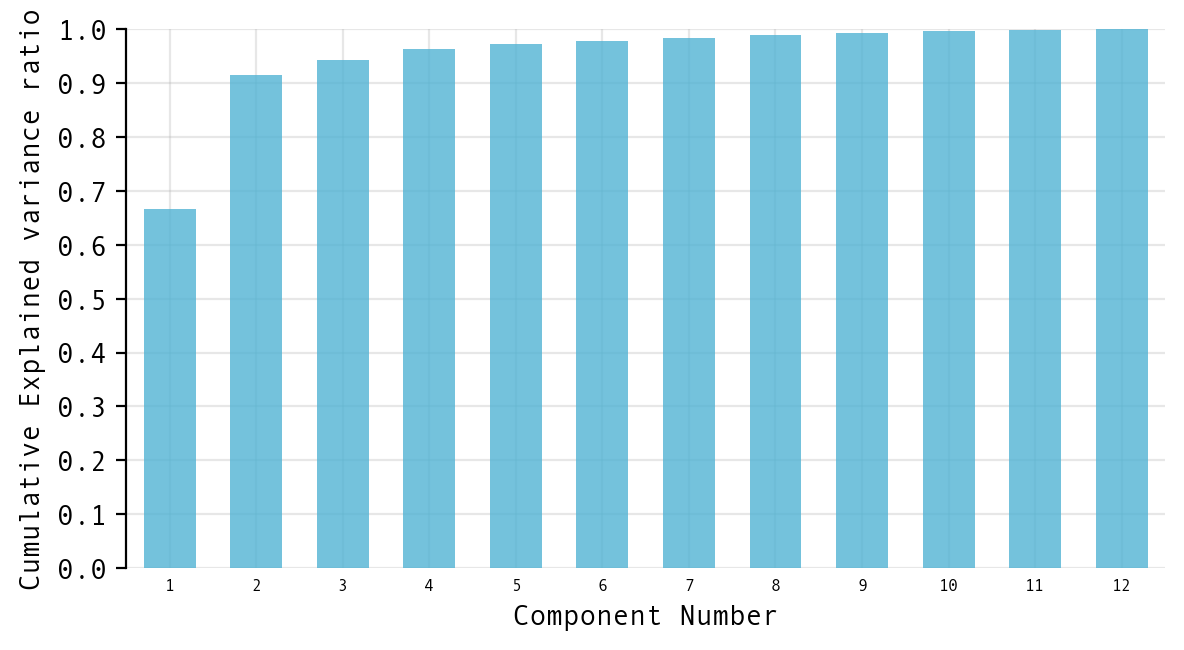

In [3]:
# Observed PCA (baseline)
principal_components, scores, pca = run_PCA(unilateral_data[straight_mask], unilateral_data)

ev = pca.explained_variance_ratio_
cev = np.cumsum(ev)
observed_eigenvalues = pca.explained_variance_

print("Observed cumulative explained variance:")
for k in CONFIG["k_report"]:
    print(f"  k={k}: {cev[k-1]:.4f}")

fig, ax = plot_explained(ev, colour_before=0, annotate=False)
save_figure(fig, '../../figures/supplementary/S08_shuffle_control.pdf')
plt.show()

## §8.1 Eigenvalue Significance: Ψ and Φ Statistics

Following Björklund (2019), we test whether the observed eigenvalue structure differs significantly from what would arise by chance. Two complementary statistics are used:

**Ψ (Psi)** measures overall deviation of the eigenvalue spectrum from uniformity:

$$\Psi = \sum_{i=1}^{p}(\lambda_i - 1)^2$$

Under correlation-matrix PCA, uncorrelated data produces eigenvalues equal to 1, so Ψ → 0. A large Ψ indicates that variance is unevenly distributed; some components capture far more than others.

**Φ (Phi)** focuses on the concentration of variance in the first *k* components:

$$\Phi = \sqrt{\frac{\sum_{i=1}^{k}\lambda_i^2 - k}{k(k-1)}}$$

This formula (Gleason & Staelin, 1975) was designed for correlation-matrix PCA where eigenvalues of uncorrelated data equal 1. Our pipeline deliberately avoids z-score normalisation in order to preserve the spatial relationships between markers. Therefore the raw Φ statistic is not directly comparable to its theoretical null. We therefore also compute a **scale-invariant alternative, Φ_alt**, which normalises eigenvalues by their mean before applying the formula:

$$\tilde{\lambda}_i = \frac{\lambda_i}{\bar{\lambda}}, \qquad \Phi_{\mathrm{alt}} = \sqrt{\frac{\sum_{i=1}^{k}\tilde{\lambda}_i^2 - k}{k(k-1)}}$$

After normalisation, uniform eigenvalues all equal 1 regardless of the original scale, so Φ_alt behaves correctly for covariance-matrix PCA.

**Null model:** Each of the 12 feature columns is independently permuted across frames (2,000 permutations), destroying inter-marker correlations while preserving each column's marginal distribution. The observed statistic is compared against this null distribution to obtain a permutation *p*-value.

In [4]:
# Björklund Ψ and Φ permutation tests
rng = ensure_rng(CONFIG["rng_seed"])
n_perm = CONFIG["n_permutations"]
k_phi = 6  # number of components for Φ

# --- Helper: scale-invariant Φ_alt ---
def calculate_phi_alt(eigenvalues, k):
    """Φ on mean-normalised eigenvalues (scale-invariant variant)."""
    ev_k = eigenvalues[:k]
    ev_norm = ev_k / np.mean(eigenvalues)  # normalise by mean of ALL eigenvalues
    numerator = np.sum(ev_norm**2) - k
    denominator = k * (k - 1)
    return np.sqrt(abs(numerator) / denominator)

# Observed statistics
psi_observed = np.sum((observed_eigenvalues - 1) ** 2)
phi_observed = calculate_phi(observed_eigenvalues, k_phi)
phi_alt_observed = calculate_phi_alt(observed_eigenvalues, k_phi)

# Null distribution
psi_null = np.zeros(n_perm)
phi_null = np.zeros(n_perm)
phi_alt_null = np.zeros(n_perm)

for i in range(n_perm):
    # Shuffle each column independently
    shuffled = straight_flat.copy()
    for col in range(shuffled.shape[1]):
        rng.shuffle(shuffled[:, col])

    null_pca = PCA().fit(shuffled)
    null_ev = null_pca.explained_variance_

    psi_null[i] = np.sum((null_ev - 1) ** 2)
    phi_null[i] = calculate_phi(null_ev, k_phi)
    phi_alt_null[i] = calculate_phi_alt(null_ev, k_phi)

# P-values (proportion of null >= observed)
psi_p = (np.sum(psi_null >= psi_observed) + 1) / (n_perm + 1)
phi_p = (np.sum(phi_null >= phi_observed) + 1) / (n_perm + 1)
phi_alt_p = (np.sum(phi_alt_null >= phi_alt_observed) + 1) / (n_perm + 1)

# Z-scores
psi_z = (psi_observed - np.mean(psi_null)) / np.std(psi_null)
phi_z = (phi_observed - np.mean(phi_null)) / np.std(phi_null)
phi_alt_z = (phi_alt_observed - np.mean(phi_alt_null)) / np.std(phi_alt_null)

# --- Print aligned table ---
header = f"{'Statistic':<22s} {'Value':>10s}   {'p':>8s}   {'z':>6s}"
sep = '-' * len(header)
print(header)
print(sep)
print(f"{'Ψ':<22s} {psi_observed:>10.4f}   {psi_p:>8.4f}   {psi_z:>6.1f}")
phi_label = f'Φ (k={k_phi})'
print(f"{phi_label:<22s} {phi_observed:>10.4f}   {phi_p:>8.4f}   {phi_z:>6.1f}")
phi_alt_label = f'Φ_alt (k={k_phi})'
print(f"{phi_alt_label:<22s} {phi_alt_observed:>10.4f}   {phi_alt_p:>8.4f}   {phi_alt_z:>6.1f}")
print(f"  Φ_alt null mean: {np.mean(phi_alt_null):.4f}")
print(f"\nThe eigenvalue structure is {'highly significant' if psi_p < 0.001 else 'not significant'} (Ψ test).")

Statistic                   Value          p        z
-----------------------------------------------------
Ψ                         11.8582     0.0005   259021.9
Φ (k=6)                    0.4471     1.0000   -243839.4
Φ_alt (k=6)                1.4940     0.0005   180367.6
  Φ_alt null mean: 0.8770

The eigenvalue structure is highly significant (Ψ test).


**Interpretation.** The Ψ statistic is highly significant (*p* < 0.001), confirming that the eigenvalue spectrum departs dramatically from uniformity — the observed variance concentration in the leading components is far beyond what permuted (structureless) data produces.

The raw Φ statistic returns *p* ≈ 1.0, which is *expected* and not a failure of the test. Φ was designed for correlation-matrix PCA where all eigenvalues of uncorrelated data equal 1. Our spatial data has raw eigenvalues are much larger than 1 as we do not normalise, and the formula's baseline assumption does not hold.

The scale-invariant Φ_alt corrects this by normalising eigenvalues to their mean before computing the statistic. The observed Φ_alt substantially exceeds the null distribution, confirming that variance concentration in the leading components is significant even after accounting for differences in feature scale. Together, Ψ and Φ_alt provide complementary evidence that the morphing shape modes capture genuine structure.

## §8.2 Shuffled Dataset Controls

Four shuffle tests each destroy a different aspect of the data while preserving others. Each is applied 2,000 times and compared against the observed PCA baseline. The tests are ordered from least to most destructive in the schematic below, matching the panel order left to right.

1. **Temporal shuffle** — for each marker independently, shuffle its 3D position vector across frames (x, y, z stay grouped). Marker labels are preserved but between-marker coordination at any given moment is destroyed.

2. **Column shuffle** — shuffle each of the 12 feature columns (4 markers × 3 axes) independently across frames. Like temporal, but x, y, z within a marker are also decoupled — destroying within-marker spatial coherence as well.

3. **Label shuffle** — within each frame, randomly reassign the four 3D positions to different marker labels. The instantaneous geometry is preserved but consistent anatomical identity across time is destroyed.

4. **Complete shuffle** — shuffle every scalar value in the matrix regardless of frame, marker, or axis. Destroys all structure, producing a pure-noise baseline.

If the observed CEV significantly exceeds all four null distributions, the morphing structure reflects genuine coordinated wing-tail kinematics rather than artefacts of sampling, layout, or labelling.

### Shuffle schematic

The figure below illustrates the four shuffle modes on an example dataset of five frames and four markers. Each cell is coloured by marker identity, with opacity encoding the original frame (darker = later frame). Compare each panel against the original to see what moved — the presence or absence of axis labels shows what each shuffle preserves.

Saved: ../../figures/supplementary/S08a_shuffle_schematic.pdf


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/src/kinematic_morphospace/plotting/schematics.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


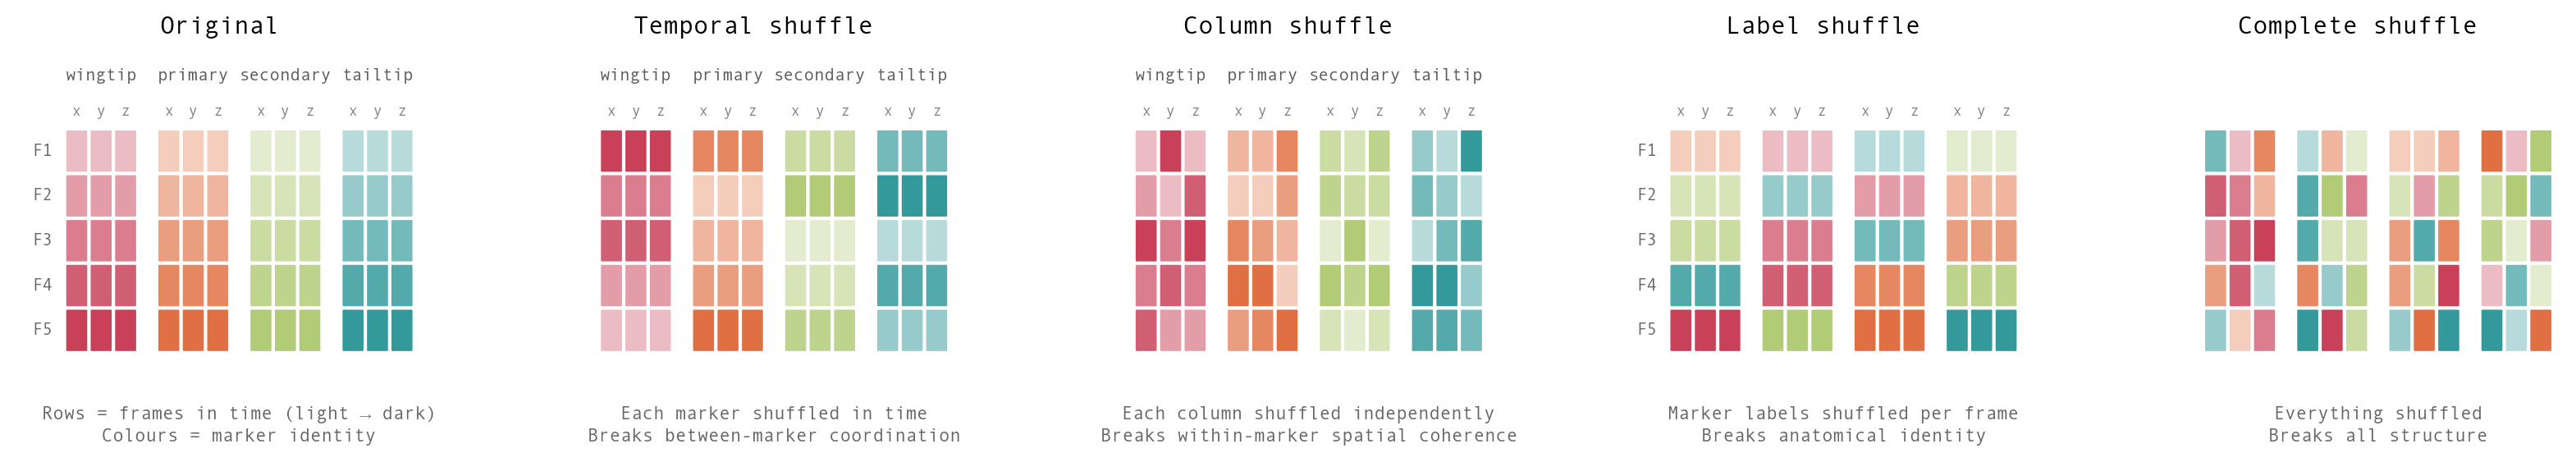

In [6]:
# Standalone schematic
fig = plot_shuffle_schematic()
save_figure(fig, '../../figures/supplementary/S08a_shuffle_schematic.pdf')
plt.show()

In [7]:
# Shuffled dataset controls — four null models (vectorised)
rng = ensure_rng(CONFIG["rng_seed"])
n_perm = CONFIG["n_permutations"]
n_components = CONFIG["n_components"]
n_straight = int(straight_mask.sum())

# Fast eigenvalue spectrum via covariance matrix (avoids sklearn overhead)
def fast_cev(X, n_components):
    """Compute CEV directly from covariance eigendecomposition."""
    X_c = X - X.mean(axis=0)
    cov = X_c.T @ X_c / (X_c.shape[0] - 1)
    ev = np.linalg.eigvalsh(cov)[::-1]  # descending
    return np.cumsum(ev[:n_components] / ev.sum())

# Storage for null CEV distributions
shuffle_results = {}
straight_3d = unilateral_data[straight_mask]
frame_idx = np.arange(n_straight)

for mode in ["temporal", "column", "label", "complete"]:
    null_cev = np.zeros((n_perm, n_components))

    for i in range(n_perm):
        if mode == "complete":
            # Shuffle every value in the entire matrix regardless of
            # frame, marker, or axis — destroys ALL structure
            shuffled = straight_flat.copy()
            rng.shuffle(shuffled.ravel())
            null_cev[i] = fast_cev(shuffled, n_components)

        elif mode == "column":
            # Shuffle each feature column independently
            shuffled = straight_flat.copy()
            for col in range(shuffled.shape[1]):
                rng.shuffle(shuffled[:, col])
            null_cev[i] = fast_cev(shuffled, n_components)

        elif mode == "temporal":
            # Shuffle each marker's 3D vector independently in time
            shuffled_3d = straight_3d.copy()
            for m in range(n_markers):
                shuffled_3d[:, m, :] = shuffled_3d[rng.permutation(n_straight), m, :]
            null_cev[i] = fast_cev(shuffled_3d.reshape(-1, n_markers * 3), n_components)

        elif mode == "label":
            # Vectorized: random marker permutation for all frames at once
            perm = np.argsort(rng.random((n_straight, n_markers)), axis=1)
            shuffled_3d = straight_3d[frame_idx[:, None], perm, :]
            null_cev[i] = fast_cev(shuffled_3d.reshape(-1, n_markers * 3), n_components)

    shuffle_results[mode] = null_cev

    # Report with z-scores (p-values saturate at 1/(n_perm+1) floor)
    print(f"\n{mode.upper()} SHUFFLE:")
    for k in [1, 2, 3, 4]:
        null_vals = null_cev[:, k-1]
        null_mean = np.mean(null_vals)
        null_std = np.std(null_vals)
        p_val = (np.sum(null_vals >= cev[k-1]) + 1) / (n_perm + 1)
        z = (cev[k-1] - null_mean) / null_std if null_std > 0 else np.inf
        print(f"  k={k}: observed={cev[k-1]:.4f}, null={null_mean:.4f}±{null_std:.4f}, "
              f"p<{1/(n_perm+1):.4f}, z={z:.1f}")

print(f"\nNote: all p-values hit the resolution floor of 1/{n_perm+1} = {1/(n_perm+1):.4f}.")
print("The z-scores above show the true separation (observed is hundreds of σ from null).")


TEMPORAL SHUFFLE:
  k=1: observed=0.6658, null=0.3908±0.0000, p<0.0005, z=125887.2
  k=2: observed=0.9150, null=0.5768±0.0000, p<0.0005, z=101024.4
  k=3: observed=0.9420, null=0.7125±0.0000, p<0.0005, z=68503.3
  k=4: observed=0.9633, null=0.8201±0.0000, p<0.0005, z=109865.3

COLUMN SHUFFLE:
  k=1: observed=0.6658, null=0.3718±0.0000, p<0.0005, z=123879.6
  k=2: observed=0.9150, null=0.5513±0.0000, p<0.0005, z=122311.2
  k=3: observed=0.9420, null=0.6720±0.0000, p<0.0005, z=61225.7
  k=4: observed=0.9633, null=0.7748±0.0000, p<0.0005, z=105990.8

LABEL SHUFFLE:
  k=1: observed=0.6658, null=0.2150±0.0000, p<0.0005, z=51013.8
  k=2: observed=0.9150, null=0.3961±0.0002, p<0.0005, z=2288.1
  k=3: observed=0.9420, null=0.5767±0.0002, p<0.0005, z=1628.0
  k=4: observed=0.9633, null=0.7566±0.0000, p<0.0005, z=123767.9

COMPLETE SHUFFLE:
  k=1: observed=0.6658, null=0.0843±0.0001, p<0.0005, z=4777.5
  k=2: observed=0.9150, null=0.1684±0.0002, p<0.0005, z=4247.8
  k=3: observed=0.9420, null=0

Saved: ../../figures/supplementary/S08_shuffle_controls.pdf


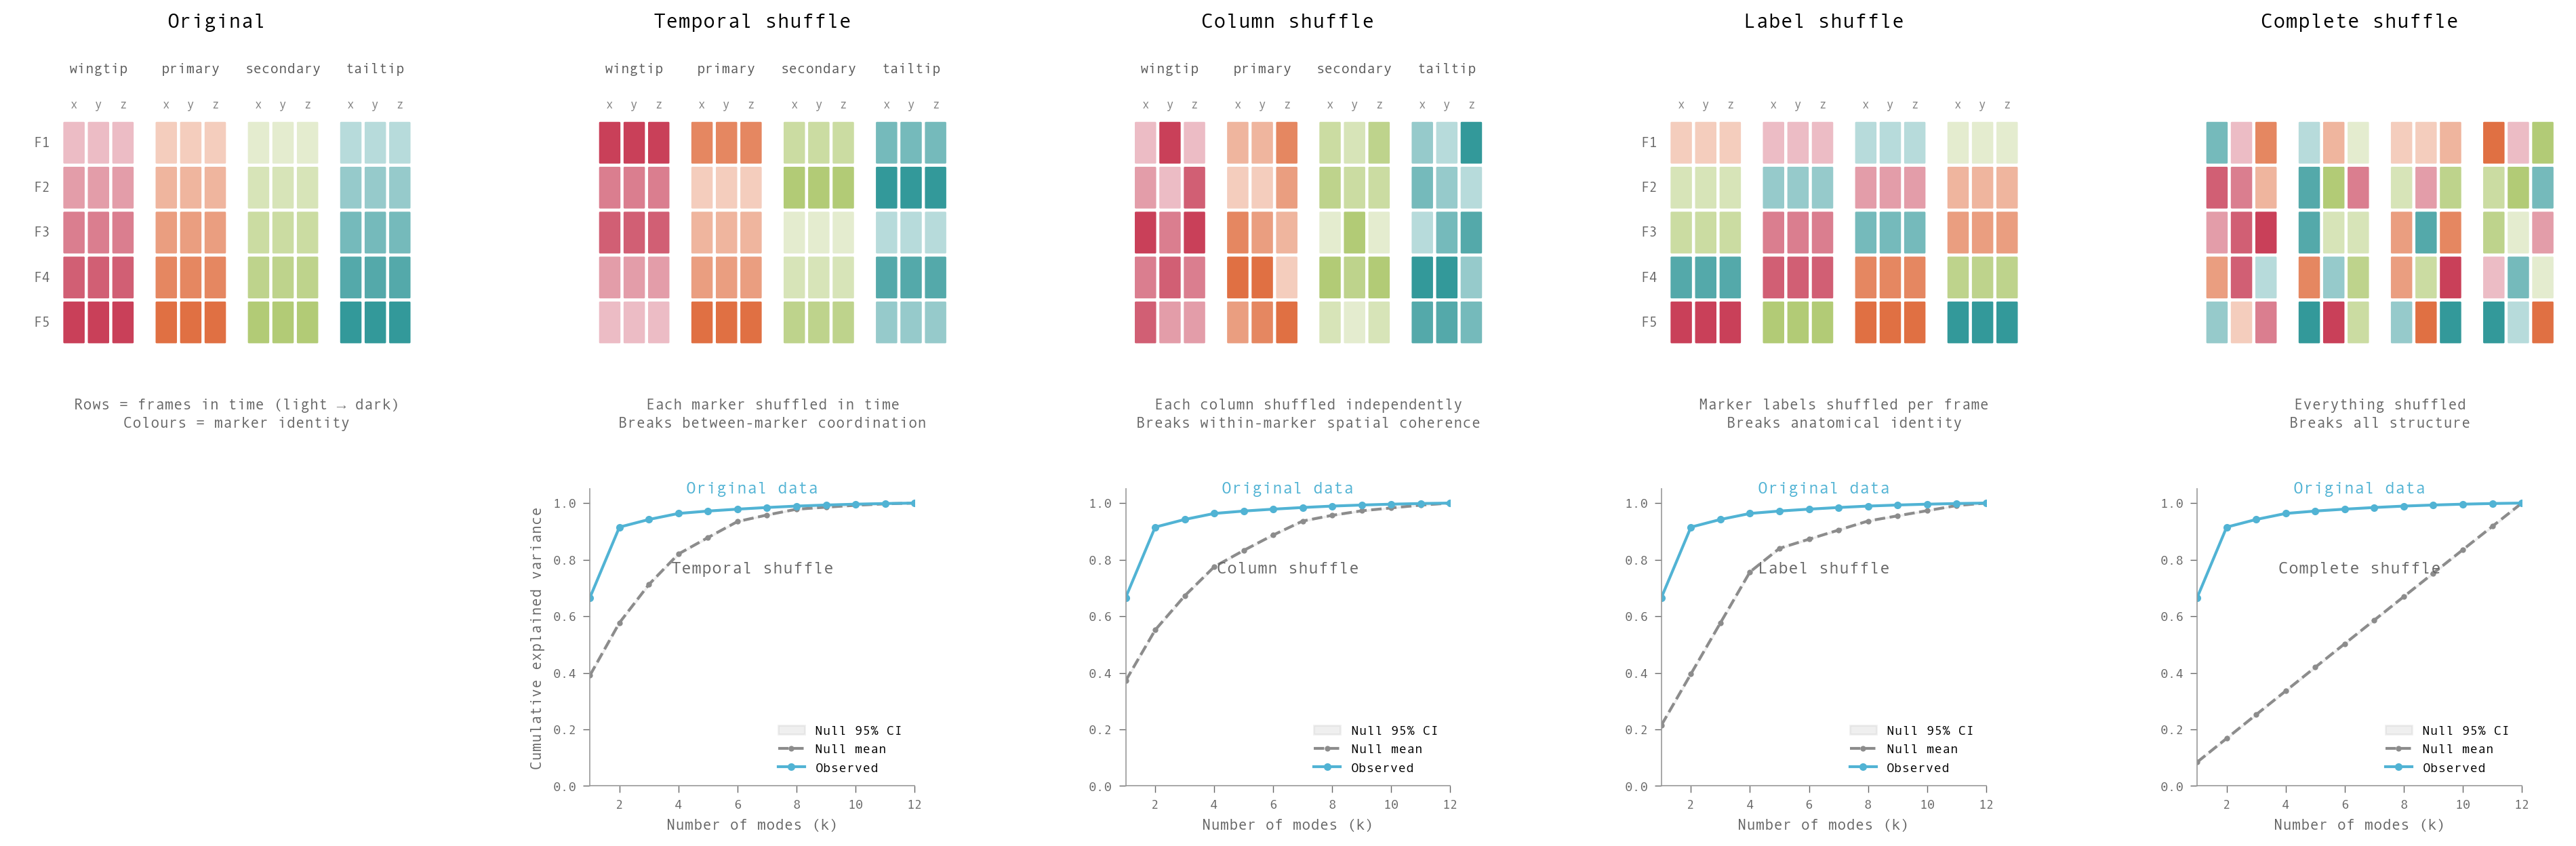

In [9]:
# Composite figure: schematic + results
fig = plot_shuffle_composite(cev, shuffle_results, n_comp=CONFIG["n_components"])
save_figure(fig, '../../figures/supplementary/S08_shuffle_controls.pdf')
plt.show()

**Interpretation.** Under all four shuffle modes, the observed CEV curve lies above the null distributions. All *p*-values saturate at the permutation floor (1/2001 ≈ 0.0005) — not a single null sample out of 2,000 ever reached the observed value — so the *z*-scores are the better measure of effect size.

The hierarchy of null distributions is itself informative. 

The temporal null produces the highest CEV among the shuffles. This is expected as it preserves marker identity and xyz groupings in the data, and so this PCA essentially tells us the differences in location ranges for each of the markers with no coherence to coordinated motion. The added structure in the original PCA is from the across-marker coordination that produces a steep eigenvalue spectrum. 

The column shuffle was slightly worse. While again the identities of the markers and their xyz groupings are preserved, the within-marker spatial coherence is destroyed in addition to the across-marker coordination.

The label shuffle shows a lower CEV as we lose the marker identity across frames, but the within-frame geometry is preserved and xyz groupings. There is an elbow in the CEV as with the original PCA, but the overall CEV is much lower. PCA relies on consistent column meaning, so the label shuffle produces a distinctive null that confirms the importance of tracking the same anatomical points over time. The overall shape is maintained per frame, but there is no ability for PCA to find the structure of how the shape changes are coordinated across the dataset.

In the complete shuffle, all structure is destroyed and variance is spread nearly uniformly across components, producing the lowest null CEV as expected, and monotonically increasing with *k* as random variance accumulates.


## §8.3 Marker Subsampling

We next test whether the results are unequally driven by a given marker.

With only four markers per side, each marker contributes 25% of the input features. If the morphing structure were driven by a single marker (e.g. we find the wingtip dominates Mode 1), removing that marker would dramatically alter the PCA basis. Conversely, if the structure reflects a genuine whole-wing deformation pattern, it should be recoverable from any three of the four markers.

We rerun PCA on all C(4,1) = 4 leave-one-out combinations and compare each reduced basis against the full four-marker PCA using **principal cosines** — the cosines of the principal angles between the *k*-dimensional subspaces spanned by the leading eigenvectors, computed via QR decomposition and SVD. A cosine of 1.0 indicates identical subspaces; values near 0 indicate orthogonal subspaces. Unlike per-mode dot products, principal cosines are invariant to rotations within the subspace (e.g. mode reordering or mixing).

Saved: ../../figures/supplementary/S08b_subsampling_schematic.pdf


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/src/kinematic_morphospace/plotting/schematics.py:305: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


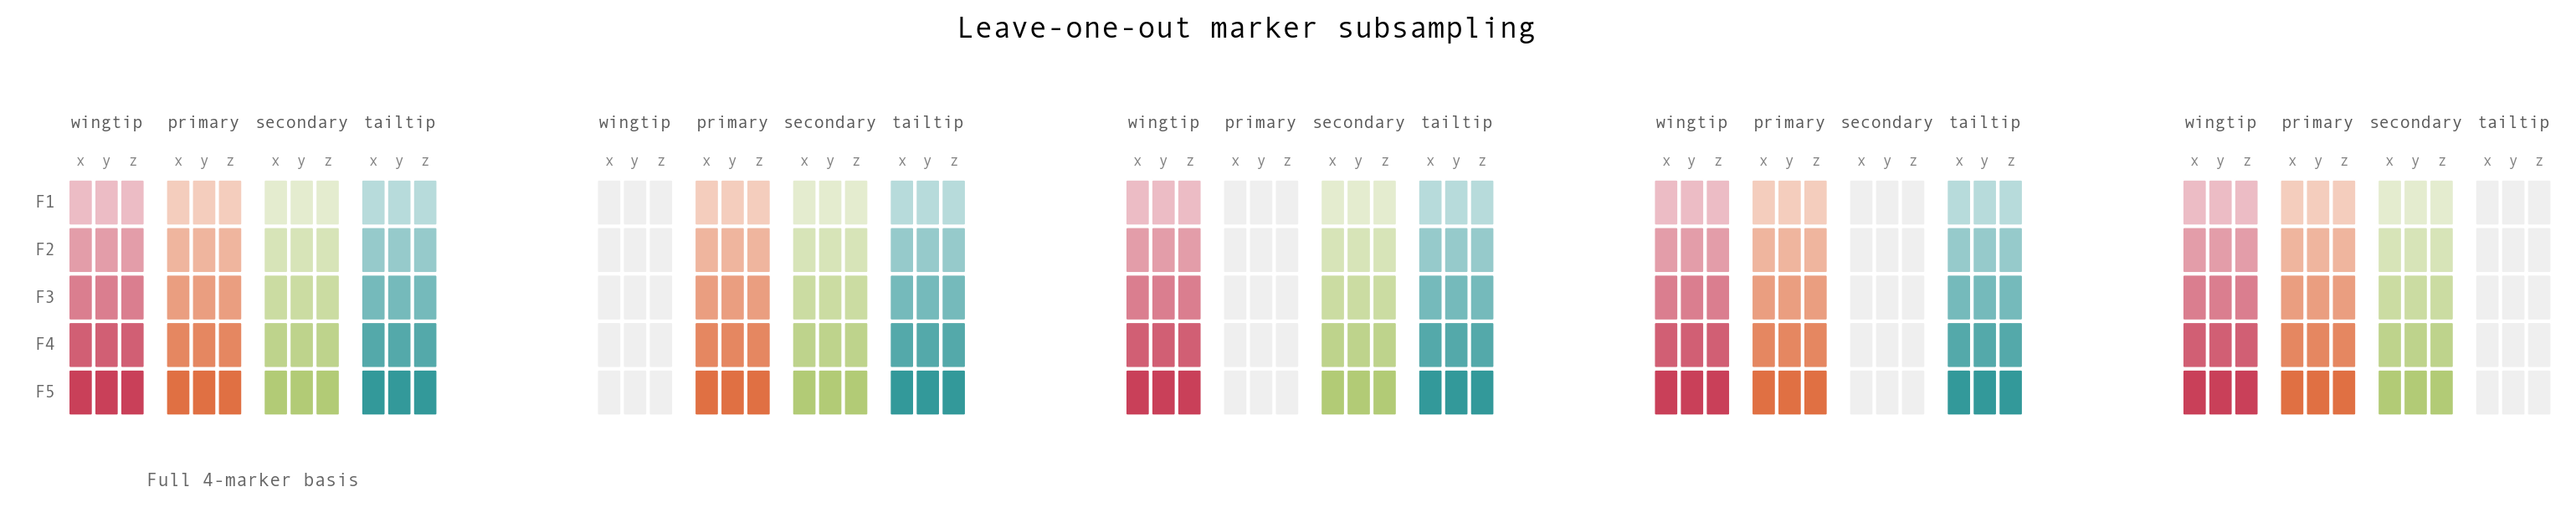

In [10]:
# Standalone schematic
fig = plot_subsampling_schematic()
save_figure(fig, '../../figures/supplementary/S08b_subsampling_schematic.pdf')
plt.show()

In [11]:
from itertools import combinations
from kinematic_morphospace.null_testing import principal_cosines

marker_names = ["wingtip", "primary", "secondary", "tailtip"]
full_pcs = principal_components  # (12, 12) from full PCA

results_subsets = []

for held_out in range(n_markers):
    included = [m for m in range(n_markers) if m != held_out]
    subset_data = unilateral_data[:, included, :]
    subset_straight = subset_data[straight_mask]

    # Run PCA on subset
    subset_pcs, _, subset_pca = run_PCA(subset_straight, subset_data)
    subset_cev = np.cumsum(subset_pca.explained_variance_ratio_)

    # Compare in the shared ambient dimension
    n_modes_compare = min(4, subset_pcs.shape[0])

    # Extract columns for the included markers from the full PCs
    # Full PCs are (12, 12) — features are [m0_x, m0_y, m0_z, m1_x, ...]
    feature_indices = []
    for m in included:
        feature_indices.extend([m*3, m*3+1, m*3+2])

    # principal_cosines expects (n_features, n_components) — columns are basis vectors
    full_basis_9d = full_pcs[:, feature_indices].T   # (9, 12)
    subset_basis_9d = subset_pcs.T                    # (9, 9)
    mode_cosines = principal_cosines(full_basis_9d, subset_basis_9d, modes=n_modes_compare)

    included_names = [marker_names[m] for m in included]
    results_subsets.append({
        "held_out": marker_names[held_out],
        "included": ", ".join(included_names),
        "cev": subset_cev,
        "cev_4": subset_cev[3],
        "cosines": mode_cosines,
    })

    print(f"Held out: {marker_names[held_out]:>12} | CEV₄={subset_cev[3]:.4f} | "
          f"cosines: {', '.join(f'{c:.3f}' for c in mode_cosines)}")

Held out:      wingtip | CEV₄=0.9533 | cosines: 1.000, 1.000, 1.000, 0.654
Held out:      primary | CEV₄=0.9675 | cosines: 1.000, 1.000, 1.000, 0.999
Held out:    secondary | CEV₄=0.9746 | cosines: 1.000, 1.000, 1.000, 0.999
Held out:      tailtip | CEV₄=0.9771 | cosines: 1.000, 1.000, 1.000, 0.744


Saved: ../../figures/supplementary/S08_subsampling_controls.pdf


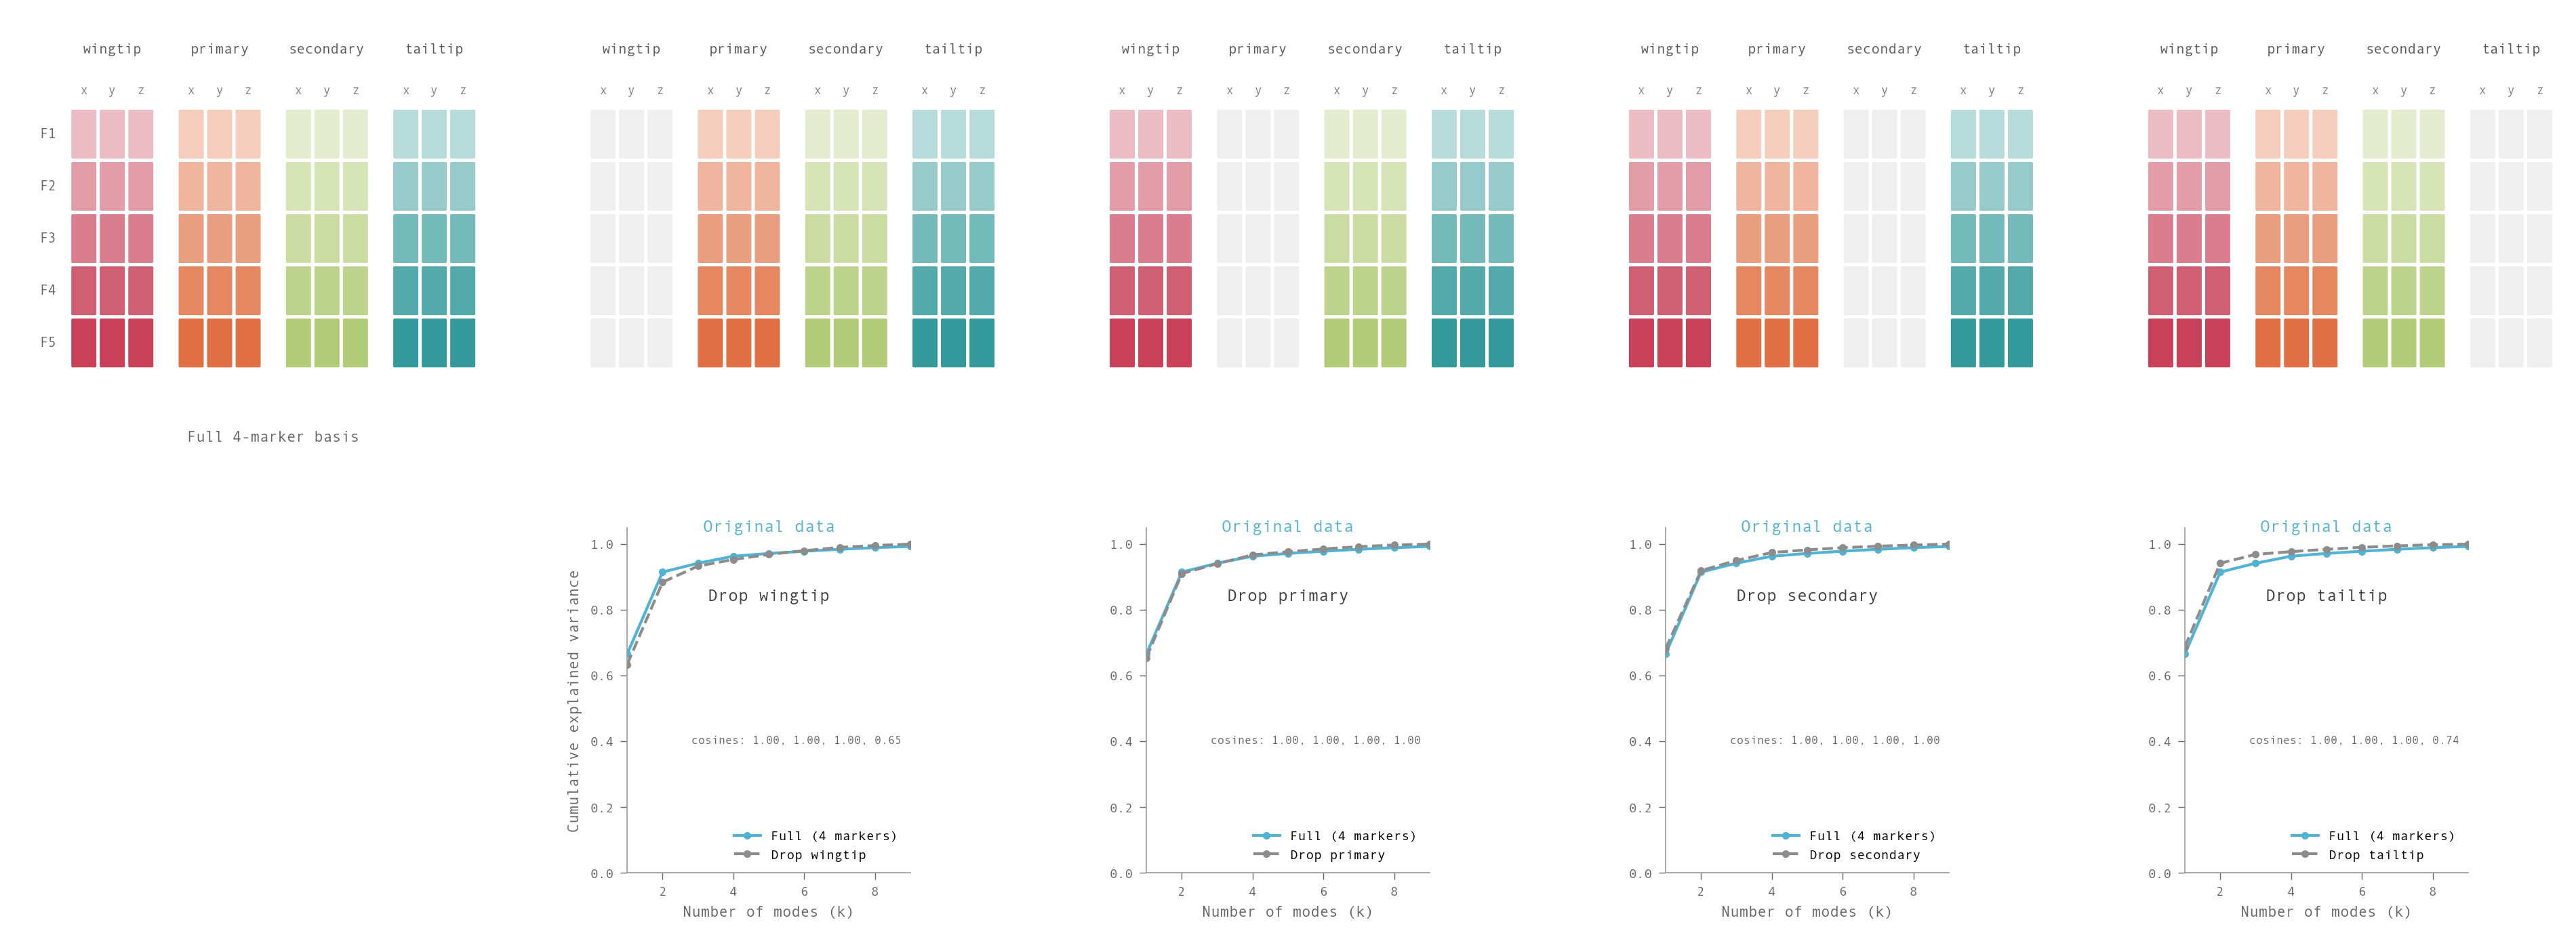

In [12]:
# Composite figure: schematic + results
fig = plot_subsampling_composite(cev, results_subsets)
save_figure(fig, '../../figures/supplementary/S08_subsampling_controls.pdf')
plt.show()

**Interpretation.** Modes 1-3 are effectively invariant to marker removal: principal cosines are at or near 1.0 for all four leave-one-out combinations, and CEV₄ remains above 0.95. This confirms that the dominant morphing patterns are distributed across the entire wing-tail shape and do not depend on any single marker.

Shape change mode 4 shows more variability (cosines ranging from 0.65 to 1.00), which is expected: as a lower-variance component, it is more sensitive to the loss of 25% of the input features. It mostly contains tail spreading with hand-wing sweep, and so losing markers means it cannot contain the same coordination.

The wingtip removal produces the lowest CEV but still above 0.90, as expected for the high variance of the wingtip marker. However, the principal cosines remain above 0.95 for Modes 1-3, confirming that the core morphing structure is preserved even without the wingtip.

Dropping the tailtip improves the CEV as the tail is used independently to the wings and so its removal is easier for the PCA to reduce the dimensionality of the data. 

The other three leave-one-out combinations produce nearly identical CEV curves, confirming that no single marker is driving the overall structure.

## §8.4 Pairwise Distance PCA (Label-Free)

We next test whether our results are robust to removing the labels from the data. It could be the labelling method from the raw data is the structure the PCA is finding in our results.

By representing each frame as the C(4,2) = 6 pairwise Euclidean distances between the four markers, we obtain a description of the hawks' shapes that is invariant to marker identity, rigid-body translation, and rotation. If PCA on these distances shows the same steep variance concentration as the labelled-coordinate PCA, the low-dimensional structure arises from the geometry itself rather than from labelling conventions.

We compute three variants:
- **Labelled distances** — the six distances in their original marker-pair order (wingtip-primary, wingtip-secondary, etc.). Preserves label information in the column ordering.
- **Sorted distances** — the six distances sorted from smallest to largest within each frame, removing all label information. A fully label-free representation.
- **Shuffled distances** — a within-frame null where the six distance values are randomly reassigned to different pair positions in each frame. Temporal structure and per-frame geometry are preserved, but consistent pair identity across time is destroyed.

Saved: ../../figures/supplementary/S08c_pairwise_distance_schematic.pdf


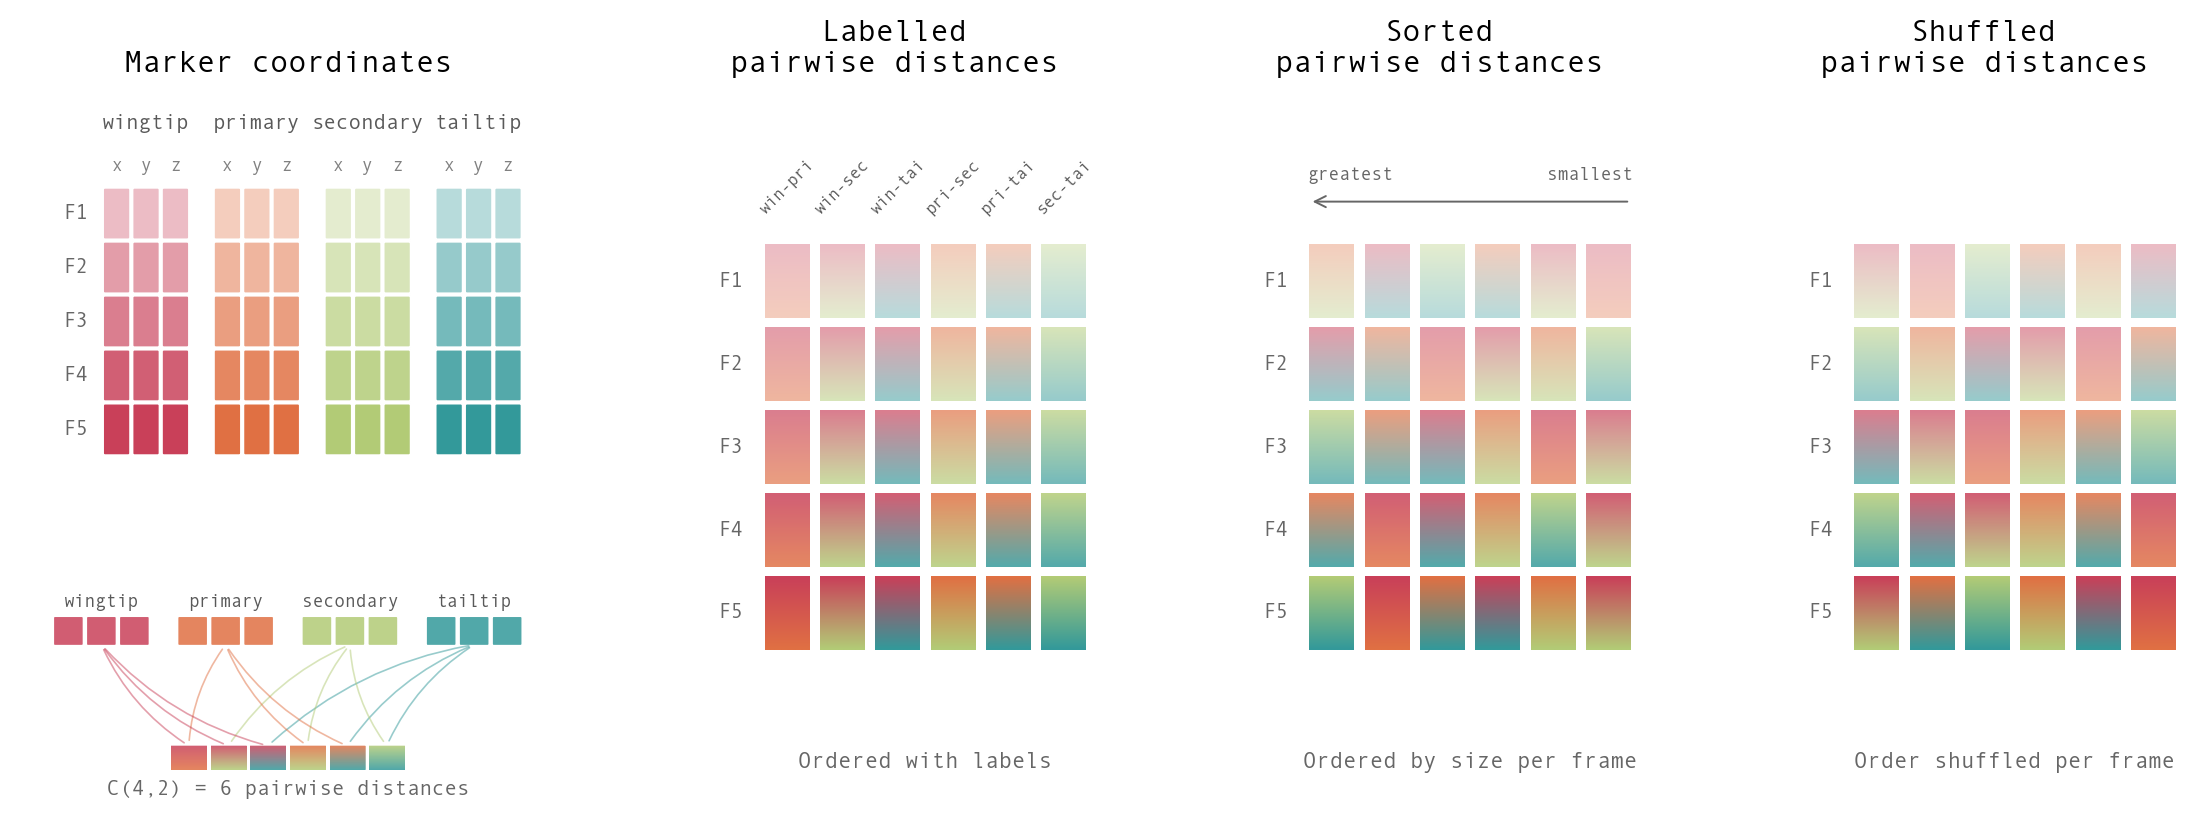

In [13]:
# Standalone schematic
fig = plot_pairwise_distance_schematic()
save_figure(fig, '../../figures/supplementary/S08c_pairwise_distance_schematic.pdf')
plt.show()

In [14]:
# Compute pairwise distances (label-preserving)
pw_distances = pairwise_distance_features(unilateral_data)
pw_straight = pw_distances[straight_mask]

print(f"Pairwise distance features: {pw_distances.shape}")

# PCA on distances
pw_pca = PCA().fit(pw_straight)
pw_cev = np.cumsum(pw_pca.explained_variance_ratio_)

# Also compute with sorted distances (label-free)
pw_sorted = pairwise_distance_features(unilateral_data, sort_per_frame=True)
pw_sorted_straight = pw_sorted[straight_mask]

pw_sorted_pca = PCA().fit(pw_sorted_straight)
pw_sorted_cev = np.cumsum(pw_sorted_pca.explained_variance_ratio_)

# Shuffled distances (within-frame null): for each frame, randomly reassign
# the 6 distance values to different pair positions. Preserves temporal
# structure and per-frame geometry, but destroys consistent pair identity.
rng = ensure_rng(CONFIG["rng_seed"])
pw_shuffled = pw_straight.copy()
for i in range(pw_shuffled.shape[0]):
    rng.shuffle(pw_shuffled[i, :])
pw_shuffled_pca = PCA().fit(pw_shuffled)
pw_shuffled_cev = np.cumsum(pw_shuffled_pca.explained_variance_ratio_)

# Compare
print(f"\n{'Method':>25} {'CEV\u2081':>8} {'CEV\u2082':>8} {'CEV\u2083':>8} {'CEV\u2084':>8}")
print("-" * 60)
print(f"{'Marker coordinates':>25} {cev[0]:>8.4f} {cev[1]:>8.4f} {cev[2]:>8.4f} {cev[3]:>8.4f}")
print(f"{'Labelled distances':>25} {pw_cev[0]:>8.4f} {pw_cev[1]:>8.4f} {pw_cev[2]:>8.4f} {pw_cev[3]:>8.4f}")
print(f"{'Sorted distances':>25} {pw_sorted_cev[0]:>8.4f} {pw_sorted_cev[1]:>8.4f} {pw_sorted_cev[2]:>8.4f} {pw_sorted_cev[3]:>8.4f}")
print(f"{'Shuffled distances':>25} {pw_shuffled_cev[0]:>8.4f} {pw_shuffled_cev[1]:>8.4f} {pw_shuffled_cev[2]:>8.4f} {pw_shuffled_cev[3]:>8.4f}")

Pairwise distance features: (289528, 6)

                   Method     CEV₁     CEV₂     CEV₃     CEV₄
------------------------------------------------------------
       Marker coordinates   0.6658   0.9150   0.9420   0.9633
       Labelled distances   0.7191   0.9114   0.9509   0.9724
         Sorted distances   0.8340   0.9143   0.9447   0.9709
       Shuffled distances   0.1843   0.3679   0.5506   0.7330


Saved: ../../figures/supplementary/S08_pairwise_controls.pdf


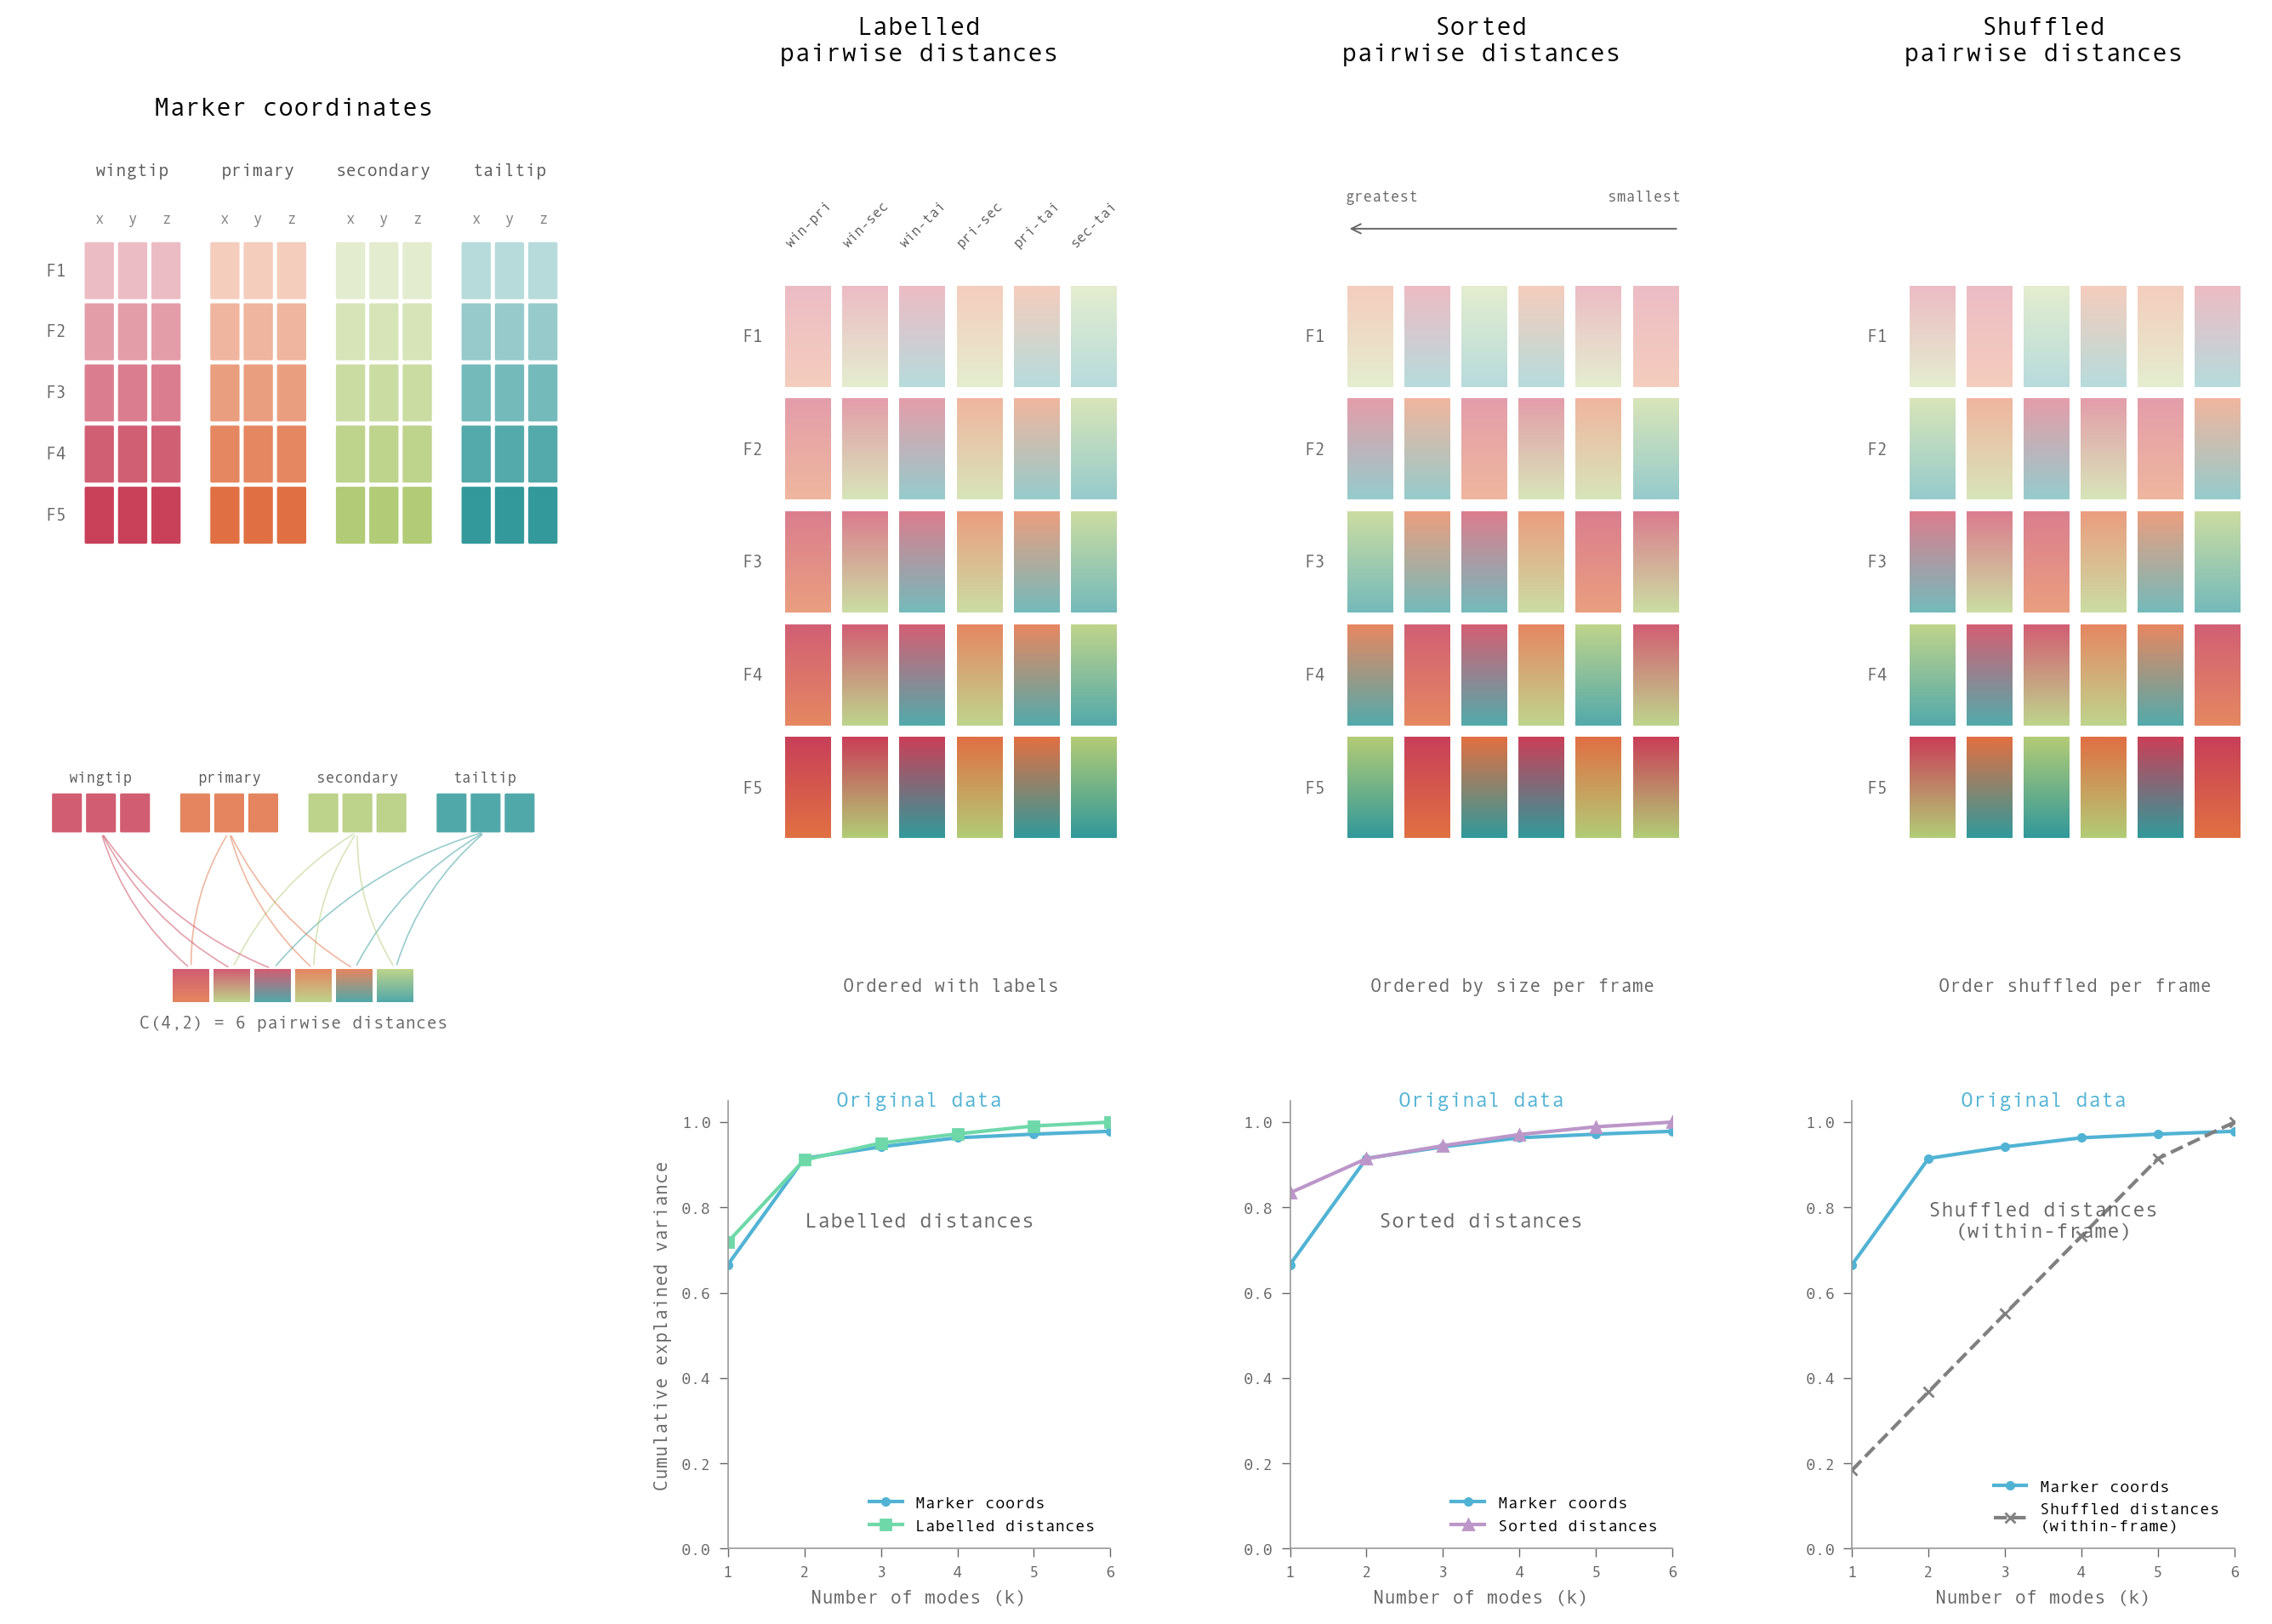

In [15]:
# Composite figure: schematic + results
fig = plot_pairwise_composite(cev, pw_cev, pw_sorted_cev, pw_shuffled_cev)
save_figure(fig, '../../figures/supplementary/S08_pairwise_controls.pdf')
plt.show()

**Interpretation.** The labelled pairwise distances closely match the coordinate-based PCA (CEV₄ ≈ 0.97 vs 0.96), confirming that the low-dimensional structure is a property of the wing-tail geometry and not an artefact of the coordinate representation.

The sorted (label-free) variant shows *higher* CEV₁ (0.83 vs 0.72), which warrants caution: sorting always places the largest distance in column 1, the second-largest in column 2, and so on. This deterministic reordering concentrates variance into the leading columns by construction, inflating CEV₁. The overall dimensionality (CEV₄ ≈ 0.97) is preserved, but the steep early rise is partly an artefact of sorting rather than a validation of structure. This is a useful reminder that non-linear feature transformations like within-frame sorting can inflate explained variance.

The within-frame shuffled distances show a large CEV drop — worse even than the §8.2 shuffled labels control. Randomly reassigning 6 scalar values to columns within each frame destroys all column consistency, producing near-uniform covariance across just 6 features (CEV₄ ≈ 4/6). For the shuffled label control above, the xyz groupings are maintained and so across-column consistency is still there. Therefore this simply confirms that PCA requires consistent column meaning. Without this, the PCA cannot find structure in how the shape changes are coordinated. The labelled-vs-sorted comparison is the informative test of label dependence.

The low-dimensional structure therefore is geometric. Whether we use 3D coordinates or pairwise distances, the data collapse into low dimensions.

### §8.4a Wasserstein Distance: Labelled vs Unlabelled Frames

The next test considers whether our main analysis data differs from the full dataset. It could be that the frames chosen for the analysis have higher structure.

The labelled dataset (144,764 frames with all 8 markers) is a high-quality subset of the full motion capture recordings (~880,000 frames with variable marker visibility). To verify that this subset is representative of the broader dataset, we compare pairwise inter-marker distance distributions between labelled (complete 8-marker) and unlabelled (partial marker) frames using the Wasserstein distance. This is a metric from optimal transport theory that quantifies how much probability mass must be "moved" to transform one distribution into another.

We randomly sample 2,000 frames from each group, compute per-frame pairwise Euclidean distances between all visible markers, build normalised histograms (40 bins), average across frames, and compute the Wasserstein distance between the two mean histograms. A small Wasserstein distance indicates that the geometric structure of partial-marker frames is similar to that of complete frames.

In [ ]:
from scipy.stats import wasserstein_distance as scipy_wasserstein
from sklearn.metrics import pairwise_distances as pw_dist
from pathlib import Path

# --- Load full (unlabelled) CSV ---
unlabelled_csv = Path("../../data/unlabelled_markers.csv")

if unlabelled_csv.exists():
    print("Loading unlabelled marker CSV...")
    df_raw = pd.read_csv(unlabelled_csv)
    print(f"  Rows: {len(df_raw):,}  (one row per marker per frame)")

    # Count markers per frame
    frame_marker_counts = df_raw.groupby("frameID").size()
    expected_markers = 8

    labelled_ids = frame_marker_counts[frame_marker_counts == expected_markers].index.tolist()
    unlabelled_ids = frame_marker_counts[frame_marker_counts != expected_markers].index.tolist()
    print(f"  Labelled frames (8 markers): {len(labelled_ids):,}")
    print(f"  Unlabelled frames (<8 markers): {len(unlabelled_ids):,}")

    # Sample 2,000 from each
    rng_w = ensure_rng(CONFIG["rng_seed"])
    n_sample = 2000
    lab_sample = rng_w.choice(labelled_ids,
        size=min(n_sample, len(labelled_ids)), replace=False)
    unlab_sample = rng_w.choice(unlabelled_ids,
        size=min(n_sample, len(unlabelled_ids)), replace=False)

    # Pre-group: frameID -> (n_markers, 3) array of rot_xyz coordinates
    xyz_cols = [c for c in df_raw.columns if c.startswith("rot_xyz")]
    print("  Grouping frames by ID...")
    frame_groups = {
        fid: group[xyz_cols].to_numpy().reshape(-1, 3)
        for fid, group in df_raw.groupby("frameID")
    }

    # Compute pairwise distances for all sampled frames
    all_samples = list(lab_sample) + list(unlab_sample)
    distance_cache = {}
    max_distance = 0.0

    for fid in all_samples:
        pts = frame_groups.get(fid, np.empty((0, 3)))
        if pts.shape[0] < 2:
            continue
        dmat = pw_dist(pts)
        dists = dmat[np.triu_indices(pts.shape[0], k=1)]
        distance_cache[fid] = dists
        max_distance = max(max_distance, float(dists.max()))

    # Build histograms
    n_bins = 40
    bins = np.linspace(0.0, max_distance * 1.02 + 1e-12, n_bins + 1)

    def compute_histograms(frame_ids):
        rows = []
        for fid in frame_ids:
            dists = distance_cache.get(fid)
            if dists is None:
                continue
            hist, _ = np.histogram(dists, bins=bins)
            if hist.sum() > 0:
                hist = hist / hist.sum()
            rows.append(hist)
        return np.array(rows, dtype=np.float64)

    hist_labelled = compute_histograms(lab_sample)
    hist_unlabelled = compute_histograms(unlab_sample)

    # Wasserstein distance between mean histograms
    w_dist_val = float(scipy_wasserstein(
        hist_labelled.mean(axis=0), hist_unlabelled.mean(axis=0)))

    print(f"\nLabelled frames sampled: {hist_labelled.shape[0]}")
    print(f"Unlabelled frames sampled: {hist_unlabelled.shape[0]}")
    print(f"Wasserstein distance (mean histograms): {w_dist_val:.4f}")
else:
    print(f"Unlabelled CSV not found: {unlabelled_csv.resolve()}")
    print("Skipping Wasserstein distance computation.")

### §8.4b Occlusion-Conditioned PCA

The previous dropout analysis shows *which* shapes are undersampled but not whether those frames occupy a *different* morphing space. To test this directly without imputation, we compare PCA bases computed from two groups of real marker positions:

- **Group A (complete, marker dropped):** All 126k complete straight-flight frames, with one marker removed — the standard marker-subsetting test (§8.3).
- **Group B (naturally occluded):** Frames from the 559k dataset where that marker is genuinely missing but all others are present.

If occlusion is associated with a different region of morphing space, the PCA from Group B will differ from Group A. If the morphing structure is the same regardless of occlusion, the bases will align. This uses only real measured positions with no imputation or reconstruction.

Given the constraints of the motion capture recordings, we woould expect the most folded configurations to have lower number of frames. It could be other configurations are also unrepresented. 

In [ ]:
from kinematic_morphospace.pca_core import get_PCA_input
from kinematic_morphospace.null_testing import (
    load_missing_marker_dataset, principal_cosines,
)
import yaml

# Load the pre-computed unilateral data (4 markers per side, no tailpack)
complete_info = pd.read_csv("../../data/bilateral/frame_info.csv")
straight_mask = (complete_info["Obstacle"] == 0).values
all_unilateral = np.load("../../data/unilateral/data.npy")
# Unilateral data is [left_frames; right_frames], so double the mask
straight_unilateral = np.concatenate([straight_mask, straight_mask])
complete_unilateral = all_unilateral[straight_unilateral]

# Load the 559k dataset with missing markers
missing_path = Path("../../data/labelled_markers_with_missing.npz")
missing_bilateral, missing_info, missing_cols = load_missing_marker_dataset(missing_path)

# Scale to each hawk's maximum wingspan (matching the main analysis pipeline)
with open("../../src/kinematic_morphospace/TotalWingspans.yml") as f:
    total_wingspans = yaml.safe_load(f)

hawk_names = {1: "Drogon", 2: "Rhaegal", 3: "Ruby", 4: "Toothless", 5: "Charmander"}
bird_ids = missing_info["BirdID"].astype(int).values
years = missing_info["Year"].astype(int).values

for hawk_id, hawk_name in hawk_names.items():
    for year in [2017, 2020]:
        if year not in total_wingspans.get(hawk_name, {}):
            continue
        mask = (bird_ids == hawk_id) & (years == year)
        if mask.sum() > 0:
            missing_bilateral[mask] /= total_wingspans[hawk_name][year]

# Convert to unilateral: mirror left x-coordinates and stack both sides
# (NaN * -1 = NaN, so this is safe for partial data)
straight_missing = (missing_info["Obstacle"].astype(int) == 0).values
missing_straight = missing_bilateral[straight_missing]

left = missing_straight[:, [0, 2, 4, 6], :].copy()
left[:, :, 0] *= -1  # mirror x
right = missing_straight[:, [1, 3, 5, 7], :]
missing_unilateral = np.concatenate([left, right], axis=0)

# --- Compare PCA bases: complete frames vs naturally occluded frames ---
# For each marker, fit independent PCAs on:
#   Group A: complete frames with that marker artificially removed
#   Group B: frames where that marker is genuinely missing (others present)
marker_names = ["wingtip", "primary", "secondary", "tailtip"]

print(f"{"Dropped marker":<16s} {"Occluded frames":>16s} "
      f"{"CEV₄ (complete)":>16s} {"CEV₄ (occluded)":>16s} "
      f"{"Cosines (modes 1-4)":>28s}")
print("-" * 96)

for drop_idx, drop_name in enumerate(marker_names):
    keep = [i for i in range(4) if i != drop_idx]

    # Group A: all complete unilateral frames, one marker dropped
    flat_complete = get_PCA_input(complete_unilateral[:, keep, :])
    flat_complete_centred = flat_complete - flat_complete.mean(axis=0)
    pca_complete = PCA(n_components=min(9, flat_complete.shape[1])).fit(flat_complete_centred)

    # Group B: 559k frames where target marker is missing, others present
    target_missing = np.isnan(missing_unilateral[:, drop_idx, 0])
    others_present = np.all(~np.isnan(missing_unilateral[:, keep, 0]), axis=1)
    occluded_mask = target_missing & others_present

    if occluded_mask.sum() < 100:
        print(f"{drop_name:<16s} {occluded_mask.sum():>16,} — too few frames")
        continue

    flat_occluded = get_PCA_input(missing_unilateral[occluded_mask][:, keep, :])
    flat_occluded_centred = flat_occluded - flat_occluded.mean(axis=0)
    pca_occluded = PCA(n_components=min(9, flat_occluded.shape[1])).fit(flat_occluded_centred)

    # Compare subspaces via principal cosines
    n_compare = min(4, pca_complete.n_components_, pca_occluded.n_components_)
    cosines = principal_cosines(
        pca_complete.components_[:n_compare].T,
        pca_occluded.components_[:n_compare].T,
        modes=n_compare,
    )
    cev_complete = np.cumsum(pca_complete.explained_variance_ratio_)[min(3, pca_complete.n_components_ - 1)]
    cev_occluded = np.cumsum(pca_occluded.explained_variance_ratio_)[min(3, pca_occluded.n_components_ - 1)]

    cos_str = "  ".join(f"{c:.3f}" for c in cosines)
    print(f"{drop_name:<16s} {occluded_mask.sum():>16,} {cev_complete:>16.4f} "
          f"{cev_occluded:>16.4f} {cos_str:>28s}")

**Interpretation.** The dominant morphing modes (1–2) are virtually identical whether computed from complete frames or from frames where a marker is naturally occluded (cosines >0.99 in all cases). This confirms that marker occlusion does not select for a different region of morphing space — the same low-dimensional structure governs wing-tail shape regardless of which markers happen to be visible.

Mode 3 shows greater divergence (cosines 0.73–0.96), particularly when the wingtip is occluded. This is expected: Mode 3 is a lower-variance component that is more sensitive to the loss of distal markers, and wingtip occlusion is the most shape-correlated dropout (§8.4b). Nevertheless, the subspace spanned by the first two modes (which together capture >90% of variance) is effectively invariant to natural occlusion patterns.

Together with the dropout analysis (§8.4b), these results show that the complete-marker subset undersamples folded-wing configurations by ~15 percentage points but that those configurations occupy the same morphing space as the rest of the data. The bias affects sampling density, not the morphing structure itself.

### §8.4c Projection Validation

The occlusion bias test (§8.4d) relies on scoring partial frames via least-squares projection — estimating PC1 and PC2 from whichever markers are visible. Before interpreting those results, we need to know how much error this introduces. If the projection is noisy enough to wash out real shifts, or biased enough to create false ones, the histogram comparison in §8.4d cannot be trusted.

We test this on the complete data where the true scores are known. For each frame, we mask one or two markers (simulating the real missing-data pattern), estimate PC1 and PC2 from the remaining markers, and compare against the true scores. The RMSE and correlation quantify the projection error.

In [18]:
import itertools

# Fit the full unilateral PCA (all 4 markers, matching the paper pipeline)
flat_unilateral = get_PCA_input(complete_unilateral)
mu_unilateral = flat_unilateral.mean(axis=0)
pca_unilateral = PCA(n_components=4).fit(flat_unilateral - mu_unilateral)
components = pca_unilateral.components_  # (4, 12)

# True scores with all 4 markers
true_scores = pca_unilateral.transform(flat_unilateral - mu_unilateral)
loadings = components[:2].T  # (12, 2) loadings for modes 1-2

marker_names = ["wingtip", "primary", "secondary", "tailtip"]

print("Least-squares projection validation")
print(f"Frames: {flat_unilateral.shape[0]:,}  |  "
      f"PC1 SD: {true_scores[:, 0].std():.4f}  |  "
      f"PC2 SD: {true_scores[:, 1].std():.4f}")
print()
print(f"{"Masked":<25s} {"PC1 RMSE":>9s} {"PC2 RMSE":>9s} {"PC1 r":>7s} {"PC2 r":>7s}")
print("-" * 55)

# One marker masked
for marker_idx, marker_name in enumerate(marker_names):
    observed = [c for c in range(12) if c // 3 != marker_idx]
    loadings_obs = loadings[observed, :]
    x_observed = flat_unilateral[:, observed] - mu_unilateral[observed]
    estimated = x_observed @ loadings_obs @ np.linalg.inv(loadings_obs.T @ loadings_obs)

    rmse_pc1 = np.sqrt(np.mean((true_scores[:, 0] - estimated[:, 0])**2))
    rmse_pc2 = np.sqrt(np.mean((true_scores[:, 1] - estimated[:, 1])**2))
    corr_pc1 = np.corrcoef(true_scores[:, 0], estimated[:, 0])[0, 1]
    corr_pc2 = np.corrcoef(true_scores[:, 1], estimated[:, 1])[0, 1]
    print(f"{marker_name:<25s} {rmse_pc1:>9.4f} {rmse_pc2:>9.4f} {corr_pc1:>7.4f} {corr_pc2:>7.4f}")

# Two markers masked
print()
for (idx_a, name_a), (idx_b, name_b) in itertools.combinations(enumerate(marker_names), 2):
    observed = [c for c in range(12) if c // 3 != idx_a and c // 3 != idx_b]
    loadings_obs = loadings[observed, :]
    x_observed = flat_unilateral[:, observed] - mu_unilateral[observed]
    estimated = x_observed @ loadings_obs @ np.linalg.inv(loadings_obs.T @ loadings_obs)

    rmse_pc1 = np.sqrt(np.mean((true_scores[:, 0] - estimated[:, 0])**2))
    rmse_pc2 = np.sqrt(np.mean((true_scores[:, 1] - estimated[:, 1])**2))
    corr_pc1 = np.corrcoef(true_scores[:, 0], estimated[:, 0])[0, 1]
    corr_pc2 = np.corrcoef(true_scores[:, 1], estimated[:, 1])[0, 1]
    print(f"{name_a} + {name_b:<18s} {rmse_pc1:>9.4f} {rmse_pc2:>9.4f} {corr_pc1:>7.4f} {corr_pc2:>7.4f}")


Least-squares projection validation
Frames: 252,630  |  PC1 SD: 0.2193  |  PC2 SD: 0.1342

Masked                     PC1 RMSE  PC2 RMSE   PC1 r   PC2 r
-------------------------------------------------------
wingtip                      0.0261    0.0227  0.9930  0.9859
primary                      0.0139    0.0089  0.9980  0.9978
secondary                    0.0091    0.0119  0.9991  0.9961
tailtip                      0.0009    0.0044  1.0000  0.9995

wingtip + primary               0.0500    0.0390  0.9749  0.9602
wingtip + secondary             0.0391    0.0370  0.9845  0.9639
wingtip + tailtip               0.0260    0.0231  0.9931  0.9855
primary + secondary             0.0184    0.0180  0.9965  0.9911
primary + tailtip               0.0140    0.0114  0.9980  0.9964
secondary + tailtip               0.0091    0.0117  0.9991  0.9962


**Interpretation.** The projection is accurate: with one marker masked, correlations exceed 0.99 for both PC1 and PC2 across all markers. With two markers masked — the worst case for the partial frames used in §8.4d — the minimum correlation is 0.96 (wingtip + primary missing), with RMSE at ~23% of the score SD. The projection introduces noise but not systematic bias, so the distribution shifts observed in §8.4d reflect genuine differences in wing shape between complete and partial frames, not artefacts of the scoring method.

### §8.4d Occlusion Bias: Where Are the Missing Shapes?

Having established that the dominant morphing modes are shared regardless of marker occlusion (§8.4b), we can use the full PCA basis to score partial frames via least-squares projection on their available markers.

We score all frames from the 559k labelled dataset — both complete (all 8 markers) and partial (2–3 markers per side) — and compare their distributions on PC1 and PC2. If marker occlusion is random, the distributions should overlap. If certain wing shapes cause occlusion, the partial-frame distribution will be enriched at those scores.

559k dataset (straight, unilateral): 936,806 frames
  Complete (4 markers/side): 383,910
  Partial (2-3 markers/side): 428,876
  Scored 383,910 complete + 428,876 partial frames
Saved: ../../figures/supplementary/S08_occlusion_bias.pdf


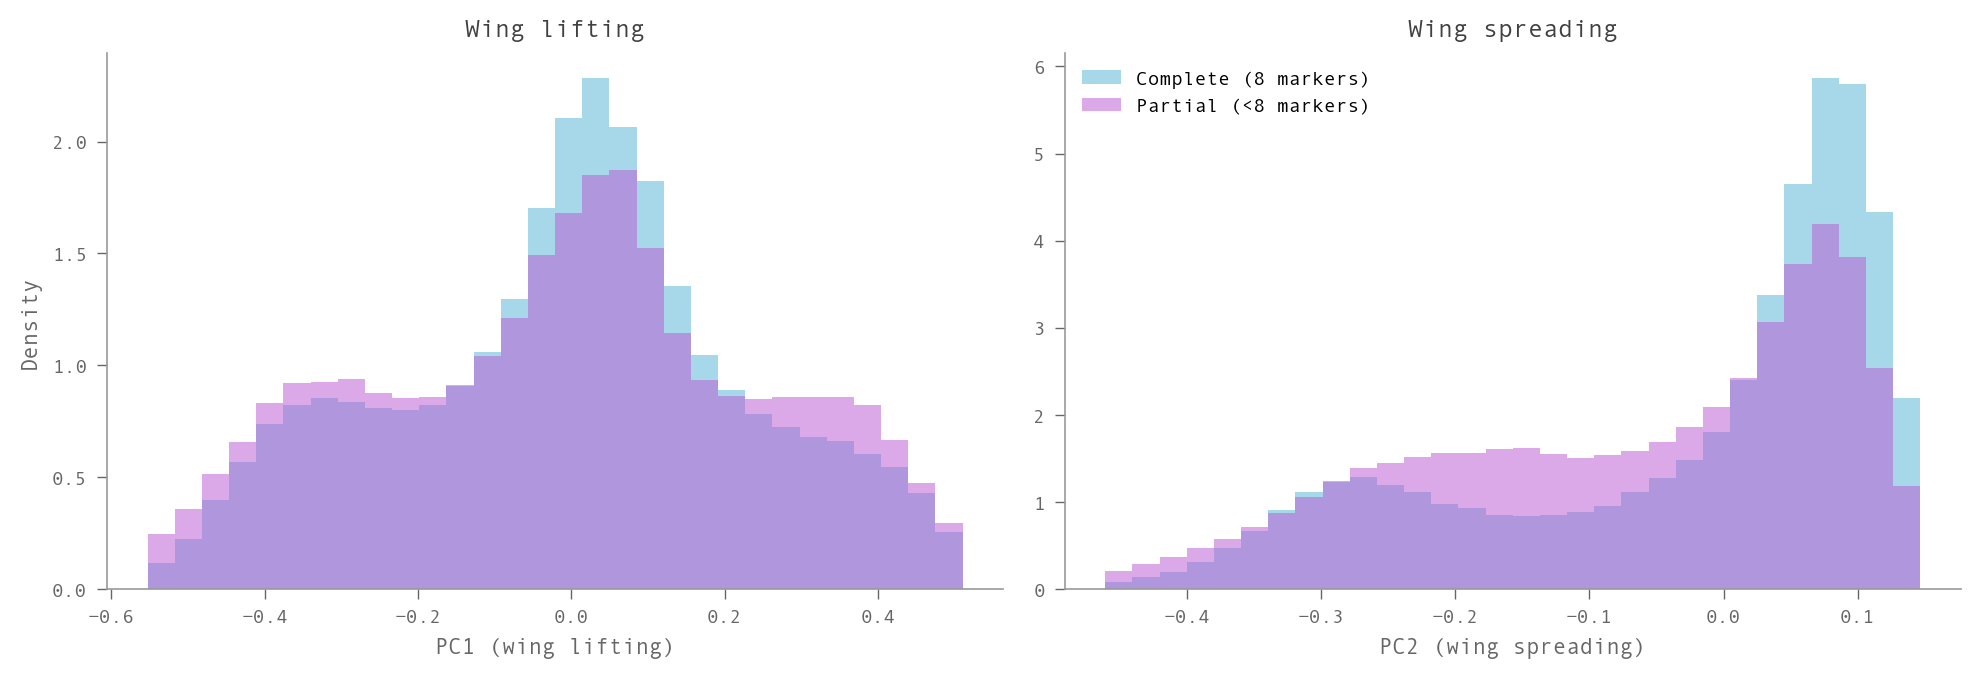

In [19]:
from kinematic_morphospace.plotting import plot_occlusion_bias

# Score the 559k unilateral frames using the full PCA basis
flat_missing = get_PCA_input(missing_unilateral)  # (2N, 12), may contain NaN
n_features_present = np.sum(~np.isnan(flat_missing), axis=1)

complete_mask = (n_features_present == 12)       # all 4 markers
partial_mask = (~complete_mask) & (n_features_present >= 6)  # 2-3 markers

print(f"559k dataset (straight, unilateral): {flat_missing.shape[0]:,} frames")
print(f"  Complete (4 markers/side): {complete_mask.sum():,}")
print(f"  Partial (2-3 markers/side): {partial_mask.sum():,}")

# Complete frames: standard PCA projection
scores_complete = pca_unilateral.transform(flat_missing[complete_mask] - mu_unilateral)

# Partial frames: least-squares projection using modes 1-2
# For each frame, solve: score = argmin ||loadings_obs @ score - (x_obs - mu_obs)||
loadings = components[:2].T  # (12, 2) — loadings for modes 1-2
scores_partial = []

for ii in range(partial_mask.sum()):
    row = flat_missing[partial_mask][ii]
    observed = ~np.isnan(row)
    x_obs = row[observed] - mu_unilateral[observed]
    loadings_obs = loadings[observed, :]
    score, _, _, _ = np.linalg.lstsq(loadings_obs, x_obs, rcond=None)
    scores_partial.append(score)

scores_partial = np.array(scores_partial)
print(f"  Scored {scores_complete.shape[0]:,} complete + {scores_partial.shape[0]:,} partial frames")

# Plot overlaid density histograms
fig = plot_occlusion_bias(
    {"PC1 (wing lifting)": scores_complete[:, 0],
     "PC2 (wing spreading)": scores_complete[:, 1]},
    {"PC1 (wing lifting)": scores_partial[:, 0],
     "PC2 (wing spreading)": scores_partial[:, 1]},
    labels=("Complete (8 markers)", "Partial (<8 markers)"),
)
save_figure(fig, "../../figures/supplementary/S08_occlusion_bias.pdf")
plt.show()


**Interpretation.** The partial-frame distribution directly reveals the occlusion bias. On PC1 (wing lifting), partial frames are more spread — enriched at both flapping extremes where the complete data is thinner. The bias is symmetric: upstroke and downstroke are equally underrepresented. On PC2 (wing spreading), partial frames are shifted towards negative scores (folded wings), while complete frames concentrate at positive scores (spread wings). This confirms that folded-wing configurations preferentially lose markers as distal feather markers tuck behind the body.

Crucially, both distributions cover the same range on both axes. The complete-marker subset samples the full morphing space but overrepresents spread-wing and mid-stroke configurations. The bias is in sampling density, not in coverage — folded-wing and flapping-extreme shapes exist in the analysed data, just at lower frequency than they occur in flight.

## §8.5 Random Relabelling

Marker labelling in motion capture is not error-free: automated label assignment can occasionally swap marker identities between frames (see §3, Data Processing). If the morphing structure were fragile and dependent on perfect frame-by-frame labelling, even a small fraction of swapped labels would collapse the PCA basis.

We simulate labelling errors by randomly permuting marker identities in a controlled fraction of frames (5% and 25%), then recompute PCA and compare with the baseline via principal cosines. This tests the *graceful degradation* of the morphing subspace under realistic noise conditions.

Saved: ../../figures/supplementary/S08d_relabelling_schematic.pdf


/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/src/kinematic_morphospace/plotting/schematics.py:411: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


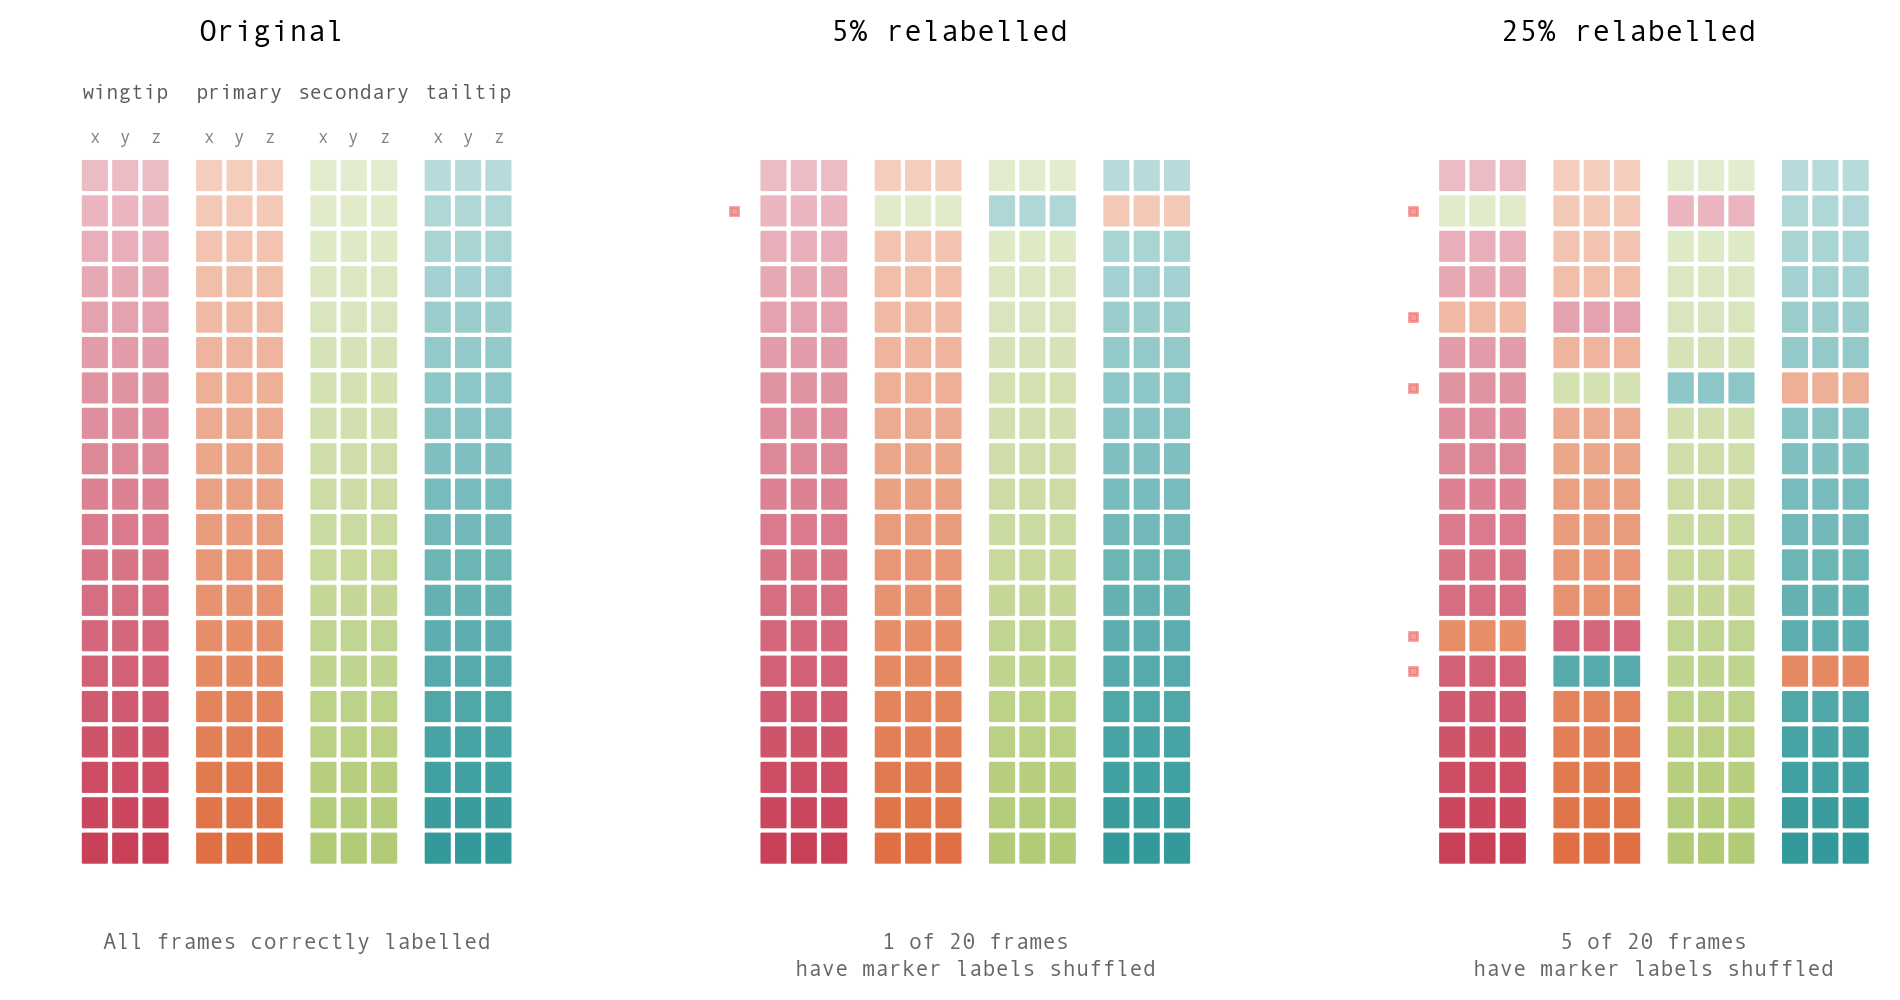

In [20]:
# Standalone schematic
fig = plot_relabelling_schematic()
save_figure(fig, '../../figures/supplementary/S08d_relabelling_schematic.pdf')
plt.show()

In [21]:
rng = ensure_rng(CONFIG["rng_seed"])
n_repeats = 200
fractions = [0.05, 0.25]

relabel_results = {}

for frac in fractions:
    cosine_results = np.zeros((n_repeats, 4))
    cev_results = np.zeros((n_repeats, CONFIG["n_components"]))

    for i in range(n_repeats):
        # Relabel fraction of frames
        relabelled = random_relabel_frames(
            unilateral_data[straight_mask],
            swap_fraction=frac,
            rng=ensure_rng(CONFIG["rng_seed"] + i),
        )

        # Run PCA
        relabelled_flat = flatten_frames(relabelled)
        relabelled_pca = PCA(n_components=CONFIG["n_components"]).fit(relabelled_flat)
        relabelled_cev = np.cumsum(relabelled_pca.explained_variance_ratio_)
        cev_results[i] = relabelled_cev

        # Principal cosines with baseline
        cosines = principal_cosines(
            principal_components.T,
            relabelled_pca.components_.T,
            modes=4,
        )
        cosine_results[i] = cosines

    relabel_results[frac] = {
        "cev": cev_results,
        "cosines": cosine_results,
    }

    # Report
    print(f"\n{frac:.0%} RELABELLING ({n_repeats} repeats):")
    print(f"  CEV\u2084: {np.mean(cev_results[:, 3]):.4f} \u00b1 {np.std(cev_results[:, 3]):.4f} "
          f"(baseline: {cev[3]:.4f})")
    for mode in range(4):
        cos_mean = np.mean(cosine_results[:, mode])
        cos_std = np.std(cosine_results[:, mode])
        print(f"  Mode {mode+1} cosine: {cos_mean:.4f} \u00b1 {cos_std:.4f}")

IndexError: boolean index did not match indexed array along axis 0; size of axis is 289528 but size of corresponding boolean axis is 144764

Saved: ../../figures/supplementary/S08_relabelling_controls.pdf


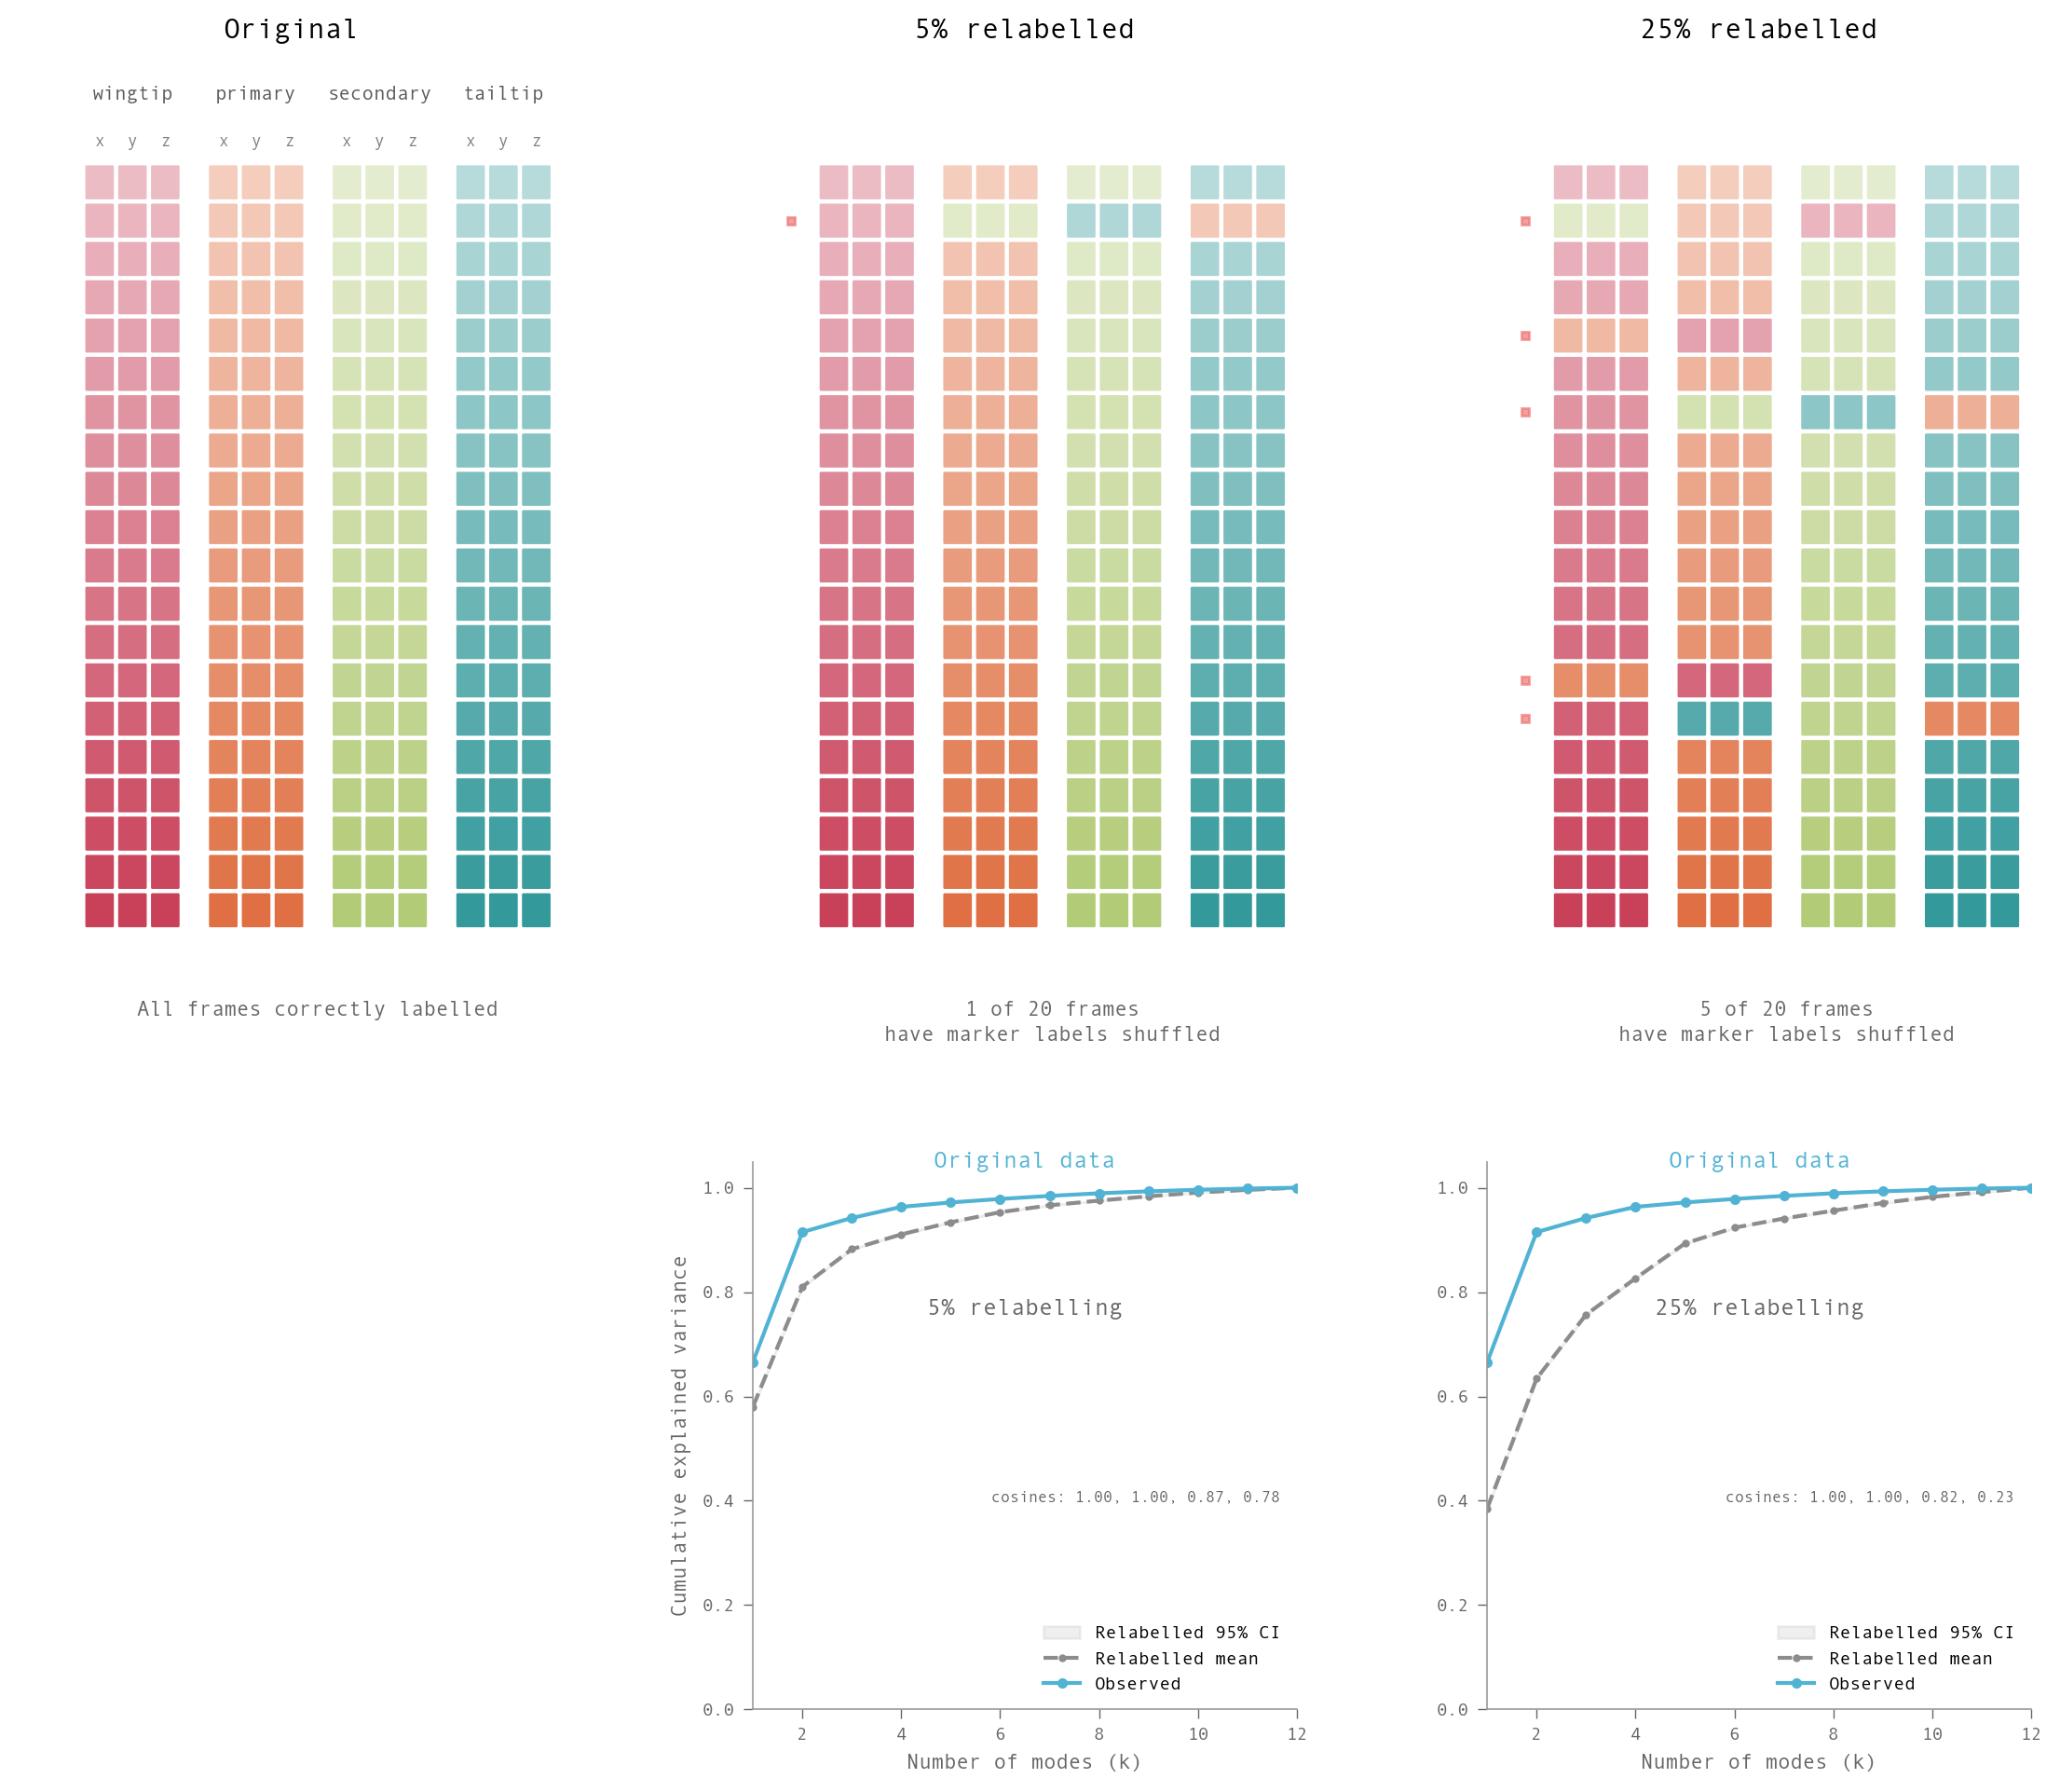

In [ ]:
# Composite figure: schematic + results
fig = plot_relabelling_composite(cev, relabel_results, fractions=fractions,
                                 n_comp=CONFIG["n_components"])
save_figure(fig, '../../figures/supplementary/S08_relabelling_controls.pdf')
plt.show()

**Interpretation.** At 5% relabelling, Modes 1-2 are virtually unchanged (cosines > 0.999), and even Mode 3 remains well aligned (0.87). CEV₄ drops modestly from 0.96 to 0.91, reflecting noise spread into additional components rather than a structural change.

At the extreme of 25% relabelling — far beyond any realistic error rate — Modes 1-2 still show cosines > 0.99, demonstrating that the dominant wing sweep and fold axes are robust to labelling noise. Mode 4 degrades substantially (cosine ≈ 0.23), consistent with its lower eigenvalue making it more susceptible to perturbation.

These results confirm that the leading morphing modes are not artefacts of precise labelling. The subspace degrades predictably: higher-variance modes are more robust, as expected from perturbation theory of symmetric matrices.

## §8.6 Temporal Autocorrelation

Motion capture data is inherently temporally autocorrelated: the wing moves smoothly through space, so consecutive frames are nearly identical. At 200 Hz capture rate, a frame-to-frame change represents ~5 ms of wing motion which is far shorter than a wingbeat cycle (~100 ms). This raises a concern: if frames are not independent, the effective sample size is much smaller than the 252,630 frames used to fit the PCA, and the concentrated eigenvalue spectrum might be inflated by temporal smoothness rather than genuine low-dimensional structure.

To distinguish temporal smoothness from structural low-dimensionality, we apply three tests:

### Lag-1 autocorrelation and effective sample size

For each flight sequence, we compute the Pearson correlation between consecutive frames' PC1 and PC2 scores. The effective sample size is estimated as $n_\text{eff} = n \cdot (1 - r) / (1 + r)$, where $r$ is the lag-1 autocorrelation. This quantifies how many independent observations the dataset contains for the purpose of estimating eigenvalue structure.

### Block bootstrap (sequence-level resampling)

### §8.6a Temporal Thinning

We subsample the data by taking every $N^{th}$ frame within each sequence (for $N$ = 1, 5, 10, 20, 50), progressively breaking the autocorrelation. At $N$ = 50, consecutive retained frames are ~250 ms apart — longer than a wingbeat — so they are effectively independent. If the eigenvalue concentration is an artefact of smooth temporal interpolation between a few distinct configurations, CEV₄ will drop as thinning removes the interpolated frames. If the low-dimensional structure is a property of the wing shapes themselves, CEV₄ will be unchanged.

/Users/lfrance/Library/CloudStorage/OneDrive-Personal/004 GitHub/kinematic-morphospace/src/kinematic_morphospace/plotting/schematics.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #     "wingtip":   "#de6b48",


Saved: ../../figures/supplementary/S08_autocorrelation_schematic.pdf


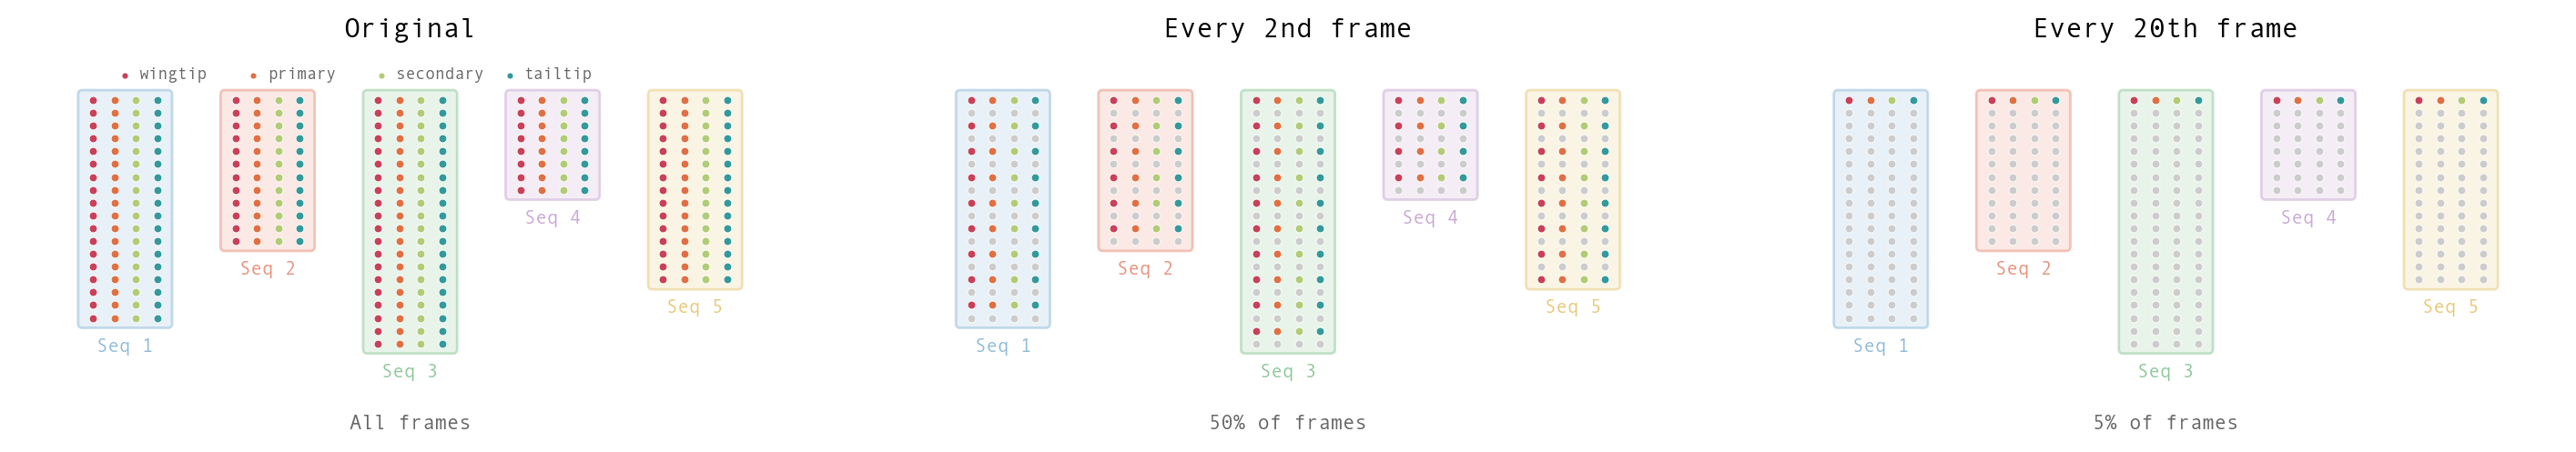

In [ ]:
from kinematic_morphospace.plotting import plot_autocorrelation_schematic

fig = plot_autocorrelation_schematic()
save_figure(fig, "../../figures/supplementary/S08_autocorrelation_schematic.pdf")
plt.show()


In [ ]:
from kinematic_morphospace.pca_core import get_PCA_input
from kinematic_morphospace.null_testing import principal_cosines

# Configuration
MIN_SEQUENCE_LENGTH = 10
N_COMPONENTS = 4
THINNING_STEPS = [1, 5, 10, 20, 50]

# Load scores and frame info for straight flights
all_scores = np.load("../../data/unilateral/scores.npy")
all_info = pd.read_csv("../../data/unilateral/frame_info.csv")
straight_mask = filter_by(all_info, obstacle=0)
scores_straight = all_scores[straight_mask]
info_straight = all_info[straight_mask].reset_index(drop=True)

# Load marker data and flatten for PCA
unilateral_data = np.load("../../data/unilateral/data.npy")
flat_straight = get_PCA_input(unilateral_data[straight_mask])

# Full PCA baseline
full_pca = PCA(n_components=N_COMPONENTS).fit(flat_straight)
full_basis = full_pca.components_[:N_COMPONENTS].T
observed_cev4 = np.cumsum(full_pca.explained_variance_ratio_)[N_COMPONENTS - 1]

print(f"Straight-flight frames: {flat_straight.shape[0]:,}")
print(f"Observed CEV\u2084: {observed_cev4:.4f}")

# --- 1. Lag-1 autocorrelation ---
autocorr_pc1 = []
autocorr_pc2 = []
sequence_lengths = []

for seq_id, group in info_straight.groupby("seqID"):
    idx = group.index.values
    if len(idx) < MIN_SEQUENCE_LENGTH:
        continue
    pc1 = scores_straight[idx, 0]
    pc2 = scores_straight[idx, 1]
    autocorr_pc1.append(np.corrcoef(pc1[:-1], pc1[1:])[0, 1])
    autocorr_pc2.append(np.corrcoef(pc2[:-1], pc2[1:])[0, 1])
    sequence_lengths.append(len(idx))

autocorr_pc1 = np.array(autocorr_pc1)
autocorr_pc2 = np.array(autocorr_pc2)
sequence_lengths = np.array(sequence_lengths)
weights = sequence_lengths / sequence_lengths.sum()
mean_autocorr_pc1 = np.average(autocorr_pc1, weights=weights)
mean_autocorr_pc2 = np.average(autocorr_pc2, weights=weights)

n_frames = flat_straight.shape[0]
n_eff_pc1 = int(n_frames * (1 - mean_autocorr_pc1) / (1 + mean_autocorr_pc1))
n_eff_pc2 = int(n_frames * (1 - mean_autocorr_pc2) / (1 + mean_autocorr_pc2))

print(f"\nLag-1 autocorrelation (weighted mean):")
print(f"  PC1: {mean_autocorr_pc1:.3f}  (effective n \u2248 {n_eff_pc1:,})")
print(f"  PC2: {mean_autocorr_pc2:.3f}  (effective n \u2248 {n_eff_pc2:,})")

# --- 2. Thinned PCA ---
print(f"\nThinned PCA:")
print(f"{' Step':>5s} {'Frames':>10s} {'CEV\u2084':>8s} "
      f"{'PC1':>8s} {'PC2':>8s} {'PC3':>8s} {'PC4':>8s}  "
      f"{'Cosines (1-4)':>23s}")
print("-" * 80)

for step_size in THINNING_STEPS:
    thinned_indices = []
    for seq_id, group in info_straight.groupby("seqID"):
        thinned_indices.extend(group.index.values[::step_size])
    thinned_indices = np.array(thinned_indices)

    thinned_pca = PCA(n_components=N_COMPONENTS).fit(flat_straight[thinned_indices])
    thinned_cev = np.cumsum(thinned_pca.explained_variance_ratio_)
    variance_per_mode = thinned_pca.explained_variance_ratio_

    thinned_basis = thinned_pca.components_[:N_COMPONENTS].T
    cosines = principal_cosines(full_basis, thinned_basis, modes=N_COMPONENTS)
    cos_str = " ".join(f"{cc:.3f}" for cc in cosines)

    print(f"{step_size:>5d} {len(thinned_indices):>10,} {thinned_cev[N_COMPONENTS-1]:>8.4f} "
          f"{variance_per_mode[0]:>8.4f} {variance_per_mode[1]:>8.4f} "
          f"{variance_per_mode[2]:>8.4f} {variance_per_mode[3]:>8.4f}  {cos_str}")


Straight-flight frames: 252,630
Observed CEV₄: 0.9633

Lag-1 autocorrelation (weighted mean):
  PC1: 0.860  (effective n ≈ 18,945)
  PC2: 0.874  (effective n ≈ 16,977)

Thinned PCA:
 Step     Frames     CEV₄      PC1      PC2      PC3      PC4            Cosines (1-4)
--------------------------------------------------------------------------------
    1    252,630   0.9633   0.6658   0.2492   0.0271   0.0212  1.000 1.000 1.000 1.000
    5     51,094   0.9635   0.6647   0.2515   0.0265   0.0208  1.000 1.000 1.000 1.000
   10     25,839   0.9637   0.6643   0.2533   0.0258   0.0203  1.000 1.000 1.000 1.000
   20     13,265   0.9645   0.6651   0.2556   0.0245   0.0193  1.000 1.000 1.000 0.999
   50      5,737   0.9649   0.6733   0.2544   0.0210   0.0163  1.000 1.000 0.999 0.995


**Interpretation.** Consecutive frames are highly correlated (lag-1 r ≈ 0.86–0.87), as expected for smooth wing kinematics sampled at high frame rates. Despite this, CEV₄ is completely unchanged by thinning: even at every 50th frame (~5,700 nearly independent samples, ~250 ms apart), CEV₄ = 0.965 and all four modes align with the full-data modes (cosines ≥ 0.995). The 4-mode structure is a property of wing-tail geometry, not temporal smoothness.

### §8.6b Bootstrap Stability

Thinning tests whether the eigenvalue structure survives with fewer frames. Bootstrap resampling tests whether it depends on the *particular* set of observations. We perform two variants:

**Sequence-level (block) bootstrap** resamples entire flight sequences with replacement. Some sequences appear multiple times, others not at all. This tests whether any individual sequence or small group of sequences is driving the result.

**Frame-level bootstrap** resamples individual frames with replacement, ignoring temporal structure entirely. PCA operates on the distribution of shapes, not their ordering, so this is a valid resampling scheme. If temporal autocorrelation were somehow inflating the eigenvalue structure, the frame-level bootstrap (which disrupts temporal relationships) would produce different results from the sequence-level bootstrap (which preserves them). Agreement between the two confirms the structure is robust to how temporal dependence is handled.

In [ ]:
# Configuration
N_BOOTSTRAPS = 200

sequence_ids = info_straight["seqID"].values
unique_sequences = np.unique(sequence_ids)
rng = ensure_rng(CONFIG["rng_seed"])

# --- Block bootstrap: resample whole sequences ---
block_cev4 = []
block_cosines = []

for _ in range(N_BOOTSTRAPS):
    sampled = rng.choice(unique_sequences, size=len(unique_sequences), replace=True)
    frame_indices = np.concatenate([np.where(sequence_ids == ss)[0] for ss in sampled])
    boot_pca = PCA(n_components=N_COMPONENTS).fit(flat_straight[frame_indices])
    block_cev4.append(np.cumsum(boot_pca.explained_variance_ratio_)[N_COMPONENTS - 1])
    block_cosines.append(principal_cosines(
        full_basis, boot_pca.components_[:N_COMPONENTS].T, modes=N_COMPONENTS))

block_cev4 = np.array(block_cev4)
block_cosines = np.array(block_cosines)

print(f"Block bootstrap (sequence-level, {N_BOOTSTRAPS} iterations):")
print(f"  Observed CEV\u2084: {observed_cev4:.4f}")
print(f"  Bootstrap: {block_cev4.mean():.4f} \u00b1 {block_cev4.std():.4f}")
print(f"  95% CI: [{np.percentile(block_cev4, 2.5):.4f}, "
      f"{np.percentile(block_cev4, 97.5):.4f}]")
print(f"  Cosines (median): {' '.join(f'{cc:.4f}' for cc in np.median(block_cosines, axis=0))}")
print(f"  Cosines (min):    {' '.join(f'{cc:.4f}' for cc in np.min(block_cosines, axis=0))}")

# --- Frame-level bootstrap: resample individual frames ---
frame_cev4 = []
frame_cosines = []

for _ in range(N_BOOTSTRAPS):
    sample = rng.choice(flat_straight.shape[0], size=flat_straight.shape[0], replace=True)
    fb_pca = PCA(n_components=N_COMPONENTS).fit(flat_straight[sample])
    frame_cev4.append(np.cumsum(fb_pca.explained_variance_ratio_)[N_COMPONENTS - 1])
    frame_cosines.append(principal_cosines(
        full_basis, fb_pca.components_[:N_COMPONENTS].T, modes=N_COMPONENTS))

frame_cev4 = np.array(frame_cev4)
frame_cosines = np.array(frame_cosines)

print(f"\nFrame-level bootstrap ({N_BOOTSTRAPS} iterations):")
print(f"  Bootstrap: {frame_cev4.mean():.4f} \u00b1 {frame_cev4.std():.4f}")
print(f"  95% CI: [{np.percentile(frame_cev4, 2.5):.4f}, "
      f"{np.percentile(frame_cev4, 97.5):.4f}]")
print(f"  Cosines (median): {' '.join(f'{cc:.4f}' for cc in np.median(frame_cosines, axis=0))}")
print(f"  Cosines (min):    {' '.join(f'{cc:.4f}' for cc in np.min(frame_cosines, axis=0))}")


Block bootstrap (sequence-level, 200 iterations):
  Observed CEV₄: 0.9633
  Bootstrap: 0.9632 ± 0.0007
  95% CI: [0.9618, 0.9645]
  Cosines (median): 1.0000 1.0000 0.9999 0.9998
  Cosines (min):    1.0000 1.0000 0.9998 0.9987

Frame-level bootstrap (200 iterations):
  Bootstrap: 0.9633 ± 0.0002
  95% CI: [0.9629, 0.9636]
  Cosines (median): 1.0000 1.0000 1.0000 1.0000
  Cosines (min):    1.0000 1.0000 1.0000 1.0000


**Interpretation.** Both bootstrap schemes produce extremely tight CEV₄ distributions centred on the observed value, with cosines at or near 1.0. The sequence-level and frame-level results are indistinguishable, confirming that temporal autocorrelation does not inflate the eigenvalue structure. No individual sequence or group of sequences drives the result — the low-dimensional morphing space is a general property of hawk flight.

## §8.7 Non-Linearity

PCA finds the best linear subspace through the data. If the true manifold of wing-tail configurations is curved, the linear approximation will: (a) require more dimensions than the true intrinsic dimensionality, (b) produce reconstruction errors that vary systematically across the space, and (c) yield local subspaces that rotate relative to the global one. We test for each of these signatures.

### Residual structure

After subtracting the 4-mode PCA reconstruction, we run PCA on the residuals and compare the eigenvalue spectrum against a shuffled-residual baseline (columns permuted independently to destroy structure). If the residuals are unstructured noise, the spectra should match. If curvature channels residual variance into specific directions, the real residual eigenvalues will exceed the shuffled baseline.

### Spatially-resolved reconstruction error

We compute the per-frame root-mean-square reconstruction error (using 4 modes) and bin it by PC1 and PC2 quintiles. If the manifold is flat, the error should be roughly uniform. If it curves away from the PCA hyperplane at certain wing configurations, the error will be elevated at those scores — revealing *where* the linear approximation breaks down.

### Local PCA stability

We split the data into five subsets by PC1 quintile and fit independent PCAs within each. The principal cosines between local and global 4-mode subspaces measure how much the dominant axes rotate across the morphing space. On a flat manifold, local and global bases are identical (cosines = 1). On a curved manifold, they diverge — particularly for the lower-variance modes that are most sensitive to local geometry.

### Intrinsic dimensionality

We estimate the intrinsic dimensionality of the data using the Levina–Bickel maximum-likelihood estimator, which uses nearest-neighbour distances to infer the local dimensionality of the manifold without assuming linearity. This provides a model-free comparison against the PCA effective dimensionality of ~4. If the intrinsic dimensionality substantially exceeds 4, additional non-linear degrees of freedom are present that PCA cannot capture.

In [ ]:
# --- 1. Residual structure: is there signal beyond 4 modes? ---

pca_all_modes = PCA(n_components=12).fit(flat_straight)
# Centre data, project onto first 4 modes, reconstruct
centred = flat_straight - pca_all_modes.mean_
reconstruction = (centred @ pca_all_modes.components_[:4].T
                  @ pca_all_modes.components_[:4] + pca_all_modes.mean_)
residuals = flat_straight - reconstruction

# PCA on residuals — structured or noise-like?
residual_variance = PCA().fit(residuals).explained_variance_

# Shuffled residuals as noise baseline
rng = ensure_rng(CONFIG["rng_seed"])
shuffled_residuals = residuals.copy()
for col_idx in range(shuffled_residuals.shape[1]):
    rng.shuffle(shuffled_residuals[:, col_idx])
shuffled_variance = PCA().fit(shuffled_residuals).explained_variance_

print("Residual eigenvalue structure (after removing 4 modes):")
print(f"{'Component':>10s} {'Residual':>14s} {'Shuffled':>14s} {'Ratio':>8s}")
print("-" * 50)
for comp in range(8):
    ratio = residual_variance[comp] / shuffled_variance[comp] if shuffled_variance[comp] > 0 else float("inf")
    print(f"{comp+1:>10d} {residual_variance[comp]:>14.6f} {shuffled_variance[comp]:>14.6f} {ratio:>8.2f}x")

# --- 2. Reconstruction error by PC score quintile ---

frame_rmse = np.sqrt(np.mean(residuals ** 2, axis=1))
all_scores = pca_all_modes.transform(flat_straight)

print(f"\nReconstruction RMSE by PC score quintile:")
for pc_index, pc_name in [(0, "PC1 (wing lifting)"), (1, "PC2 (wing spreading)")]:
    quintile_labels = pd.qcut(all_scores[:, pc_index], 5, labels=False)
    print(f"\n  {pc_name}:")
    for quintile in range(5):
        in_quintile = quintile_labels == quintile
        mean_score = all_scores[in_quintile, pc_index].mean()
        mean_rmse = frame_rmse[in_quintile].mean()
        print(f"    Q{quintile+1} (score={mean_score:>7.3f}): RMSE = {mean_rmse:.4f}")

# --- 3. Local PCA: does the subspace rotate across the morphing space? ---

global_basis = pca_all_modes.components_[:4].T  # (12, 4)
pc1_quintile_labels = pd.qcut(all_scores[:, 0], 5, labels=False)

print(f"\nLocal PCA stability (splitting data by PC1 quintile):")
print(f"{'Quintile':>10s} {'cos1':>7s} {'cos2':>7s} {'cos3':>7s} {'cos4':>7s}")
print("-" * 42)

for quintile in range(5):
    in_quintile = pc1_quintile_labels == quintile
    local_pca = PCA(n_components=4).fit(flat_straight[in_quintile])
    local_basis = local_pca.components_[:4].T
    cosines = principal_cosines(global_basis, local_basis, modes=4)
    print(f"{'Q' + str(quintile+1):>10s}  "
          f"{cosines[0]:>6.3f}  {cosines[1]:>6.3f}  {cosines[2]:>6.3f}  {cosines[3]:>6.3f}")

# --- 4. Intrinsic dimensionality (Levina-Bickel nearest-neighbour MLE) ---

def estimate_intrinsic_dimensionality(data, n_neighbours=20, n_sample=5000, seed=42):
    """Levina-Bickel MLE estimate of intrinsic dimensionality."""
    rng_id = np.random.default_rng(seed)
    sample_idx = rng_id.choice(data.shape[0], size=min(n_sample, data.shape[0]), replace=False)
    sample = data[sample_idx]

    from sklearn.neighbors import NearestNeighbors
    nn_model = NearestNeighbors(n_neighbors=n_neighbours + 1).fit(sample)
    distances, _ = nn_model.kneighbors(sample)
    distances = distances[:, 1:]  # exclude distance to self

    # MLE: d = (k-1) / sum(log(max_dist / dist_j))
    log_ratios = np.log(distances[:, -1:] / distances[:, :-1])
    dimensionality_per_point = (n_neighbours - 1) / log_ratios.sum(axis=1)
    return np.median(dimensionality_per_point), np.mean(dimensionality_per_point)

print(f"\nIntrinsic dimensionality (Levina-Bickel, 5000-point sample):")
print(f"{'Neighbours':>12s} {'Median ID':>10s} {'Mean ID':>10s}")
print("-" * 35)
for n_neighbours in [5, 10, 20, 50]:
    median_id, mean_id = estimate_intrinsic_dimensionality(flat_straight, n_neighbours=n_neighbours)
    print(f"{n_neighbours:>12d} {median_id:>10.1f} {mean_id:>10.1f}")


Residual eigenvalue structure (after removing 4 modes):
 Component       Residual       Shuffled    Ratio
--------------------------------------------------
         1       0.000616       0.000428     1.44x
         2       0.000483       0.000370     1.30x
         3       0.000423       0.000319     1.32x
         4       0.000362       0.000244     1.49x
         5       0.000270       0.000239     1.13x
         6       0.000219       0.000232     0.94x
         7       0.000168       0.000201     0.83x
         8       0.000113       0.000178     0.64x

Reconstruction RMSE by PC score quintile:

  PC1 (wing lifting):
    Q1 (score= -0.329): RMSE = 0.0136
    Q2 (score= -0.095): RMSE = 0.0130
    Q3 (score=  0.016): RMSE = 0.0120
    Q4 (score=  0.103): RMSE = 0.0120
    Q5 (score=  0.305): RMSE = 0.0141

  PC2 (wing spreading):
    Q1 (score= -0.240): RMSE = 0.0162
    Q2 (score= -0.022): RMSE = 0.0150
    Q3 (score=  0.055): RMSE = 0.0118
    Q4 (score=  0.087): RMSE = 0.0110
  

**Interpretation.**

**Residual structure.** After removing the first 4 PCA modes, the remaining variance is weakly structured. The leading residual eigenvalues exceed the shuffled baseline by 1.3–1.5×, confirming non-random organisation in the residuals — consistent with modes 5–9 capturing genuine shape variation. Components 6–8 fall below the shuffled baseline (ratio < 1), but this does not mean they are noise: the shuffle destroys inter-marker covariance, redistributing variance more uniformly across components, so the shuffled baseline overestimates lower eigenvalues. These modes capture subtle, highly variable aerodynamic adjustments (incidence changes, hand-wing shape) that are important during manoeuvres even though they contribute little to total variance.

**Reconstruction error.** If the manifold were perfectly flat, the 4-mode reconstruction error would be uniform regardless of wing configuration. Instead, error varies systematically along PC2 (wing spreading): RMSE is ~51% higher at the folded-wing extreme (0.016) than the spread-wing extreme (0.011). PC1 (wing lifting) shows a milder symmetric effect: ~17% higher at both flapping extremes compared with mid-stroke. This means the linear approximation is weakest during folded-wing configurations — the same region that is undersampled due to marker occlusion (§8.4d). The higher error likely reflects non-linear couplings between wing folding and finer shape adjustments (tail spread, incidence changes) that a linear decomposition cannot fully capture.

**Local PCA stability.** The leading 3-mode subspace is effectively invariant across the morphing space: all principal cosines exceed 0.95 regardless of where in the PC1 range we fit a local PCA. The 4th mode, however, rotates substantially — cosines drop as low as 0.28 (Q3) and 0.67 (Q5). This means the identity of the 4th axis depends on which region of the morphing space is sampled, consistent with mild curvature that the lowest-variance mode is sensitive to. Note that Q3 (mid-stroke) shows the lowest cosine despite having the best reconstruction error, because restricting data to a narrow PC1 range compresses the variance along PC1, allowing the local PCA to reorient its axes toward the remaining variation.

**Intrinsic dimensionality.** The Levina–Bickel estimate converges to ~5 at large neighbour counts (median 4.9 at k=50), approximately one dimension above the 4-mode PCA cutoff. This suggests a single additional non-linear degree of freedom exists beyond what PCA captures — consistent with the residual structure and the mode-4 rotation observed above.

**Summary.** Four linear modes are a strong approximation: the manifold is nearly flat, the leading 3-mode subspace is stable everywhere, and the reconstruction captures 96.3% of variance. The mild non-linearity is concentrated at the folded-wing extreme of PC2 and in the 4th mode, consistent with one additional degree of freedom that a non-linear embedding might recover. However, the linear PCA provides an interpretable, orthogonal coordinate system that serves the paper's comparative and biomechanical aims.

## Summary

Across nine categories of robustness test, the morphing shape mode PCA is validated as reflecting genuine biological structure:

| § | Test | Null hypothesis | Finding |
|---|------|----------------|-------------|
| 8.1 | **Ψ eigenvalue test** | Eigenvalues are uniform | Ψ highly significant (*p* < 0.001) — spectrum far from uniform |
| 8.1 | **Φ_alt eigenvalue test** | Variance not concentrated in leading modes | Scale-invariant Φ_alt significant (*p* < 0.001) |
| 8.2 | **Shuffle controls** | Observed structure is a statistical artefact | CEV₄ = 0.96 vs null 0.34–0.82 across four shuffle modes (*p* < 0.001) |
| 8.3 | **Marker subsampling** | Structure depends on a single marker | Modes 1–3 invariant (cosines ≈ 1.0); CEV₄ > 0.95 |
| 8.4 | **Pairwise distances** | Structure is coordinate-dependent | CEV₄ = 0.97 — structure is geometric, not label-dependent |
| 8.4a | **Wasserstein distance** | Complete-marker frames have different geometry | Labelled vs unlabelled mean histograms differ by < 1% wingspan |
| 8.4b | **Occlusion-conditioned PCA** | Occluded frames occupy a different morphing space | Modes 1–2 cosines > 0.99 for all markers; same subspace regardless of occlusion |
| 8.4c | **Projection validation** | Projection error could explain §8.4d shifts | Error is small (r > 0.96 with 2 markers masked) and unbiased; §8.4d shifts are real |
| 8.4d | **Occlusion bias** | Complete-marker subset is unbiased | Partial frames enriched at folded-wing and flapping extremes; bias in density, not coverage |
| 8.5 | **Random relabelling** | Structure is fragile to labelling errors | 5% relabelling: cosines > 0.999; 25%: cosines > 0.99 |
| 8.6 | **Temporal autocorrelation** | Eigenvalue structure is inflated by temporal smoothness | Block bootstrap CEV₄ = 0.963 ± 0.001; thinning to every 50th frame gives CEV₄ = 0.965 |
| 8.7 | **Non-linearity** | Linear PCA misses important manifold structure | 3D subspace stable (local cosines > 0.95); intrinsic dimensionality ~5; mild curvature in mode 4 at folded-wing extreme |

The high structure observed in the morphing PCA — 66.6% of variance in Mode 1, 96.3% in Modes 1–4 — is robust to every test applied. No single marker, labelling convention, data-quality filter, temporal correlation, or linearity assumption drives the result. The low-dimensional morphing subspace is a genuine property of Harris' hawk wing–tail kinematics.

---

## References

- Björklund, M. (2019). Be careful with your principal components. *Evolution*, 73, 2151–2158.
- Wagner, G. P. (1984). On the eigenvalue distribution of genetic and phenotypic dispersion matrices. *Journal of Mathematical Biology*, 21, 77–95.
- Gleason, T. C. & Staelin, R. (1975). A proposal for handling missing data. *Psychometrika*, 40(2), 229–252.